# new reworked notebook

✅ Imports complete.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PIPELINE GOAL (Business Context)  v2.0 — Realistic Labels
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AML rule engines generate thousands of alerts per day.
  90-95% are FALSE POSITIVES — innocent transactions flagged.
  Analysts waste enormous time reviewing noise.

  This pipeline trains a model to separate TRUE POSITIVES
  (real money laundering → file STR) from FALSE POSITIVES
  (safe to suppress).

  LABEL SOURCE (v2 — the real way):
    Ground truth comes from INVESTIGATOR DECISIONS on cases:
    CASE_STATUS = CLOSED_SAR_FILED      → IS_TRUE_POS = 1
    CASE_STATUS = CLOSED_FALSE_POSITIVE → IS_TRUE_POS = 0
    CASE_STATUS = CLOSED_MONITORING     → IS_TRUE_POS = 0
    CASE_STATUS = OPEN                  → EXCLUDED (unknown)

  This mirrors how AMLOCS / Actimize / Finacle case management
  systems record analyst decisions in practice.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

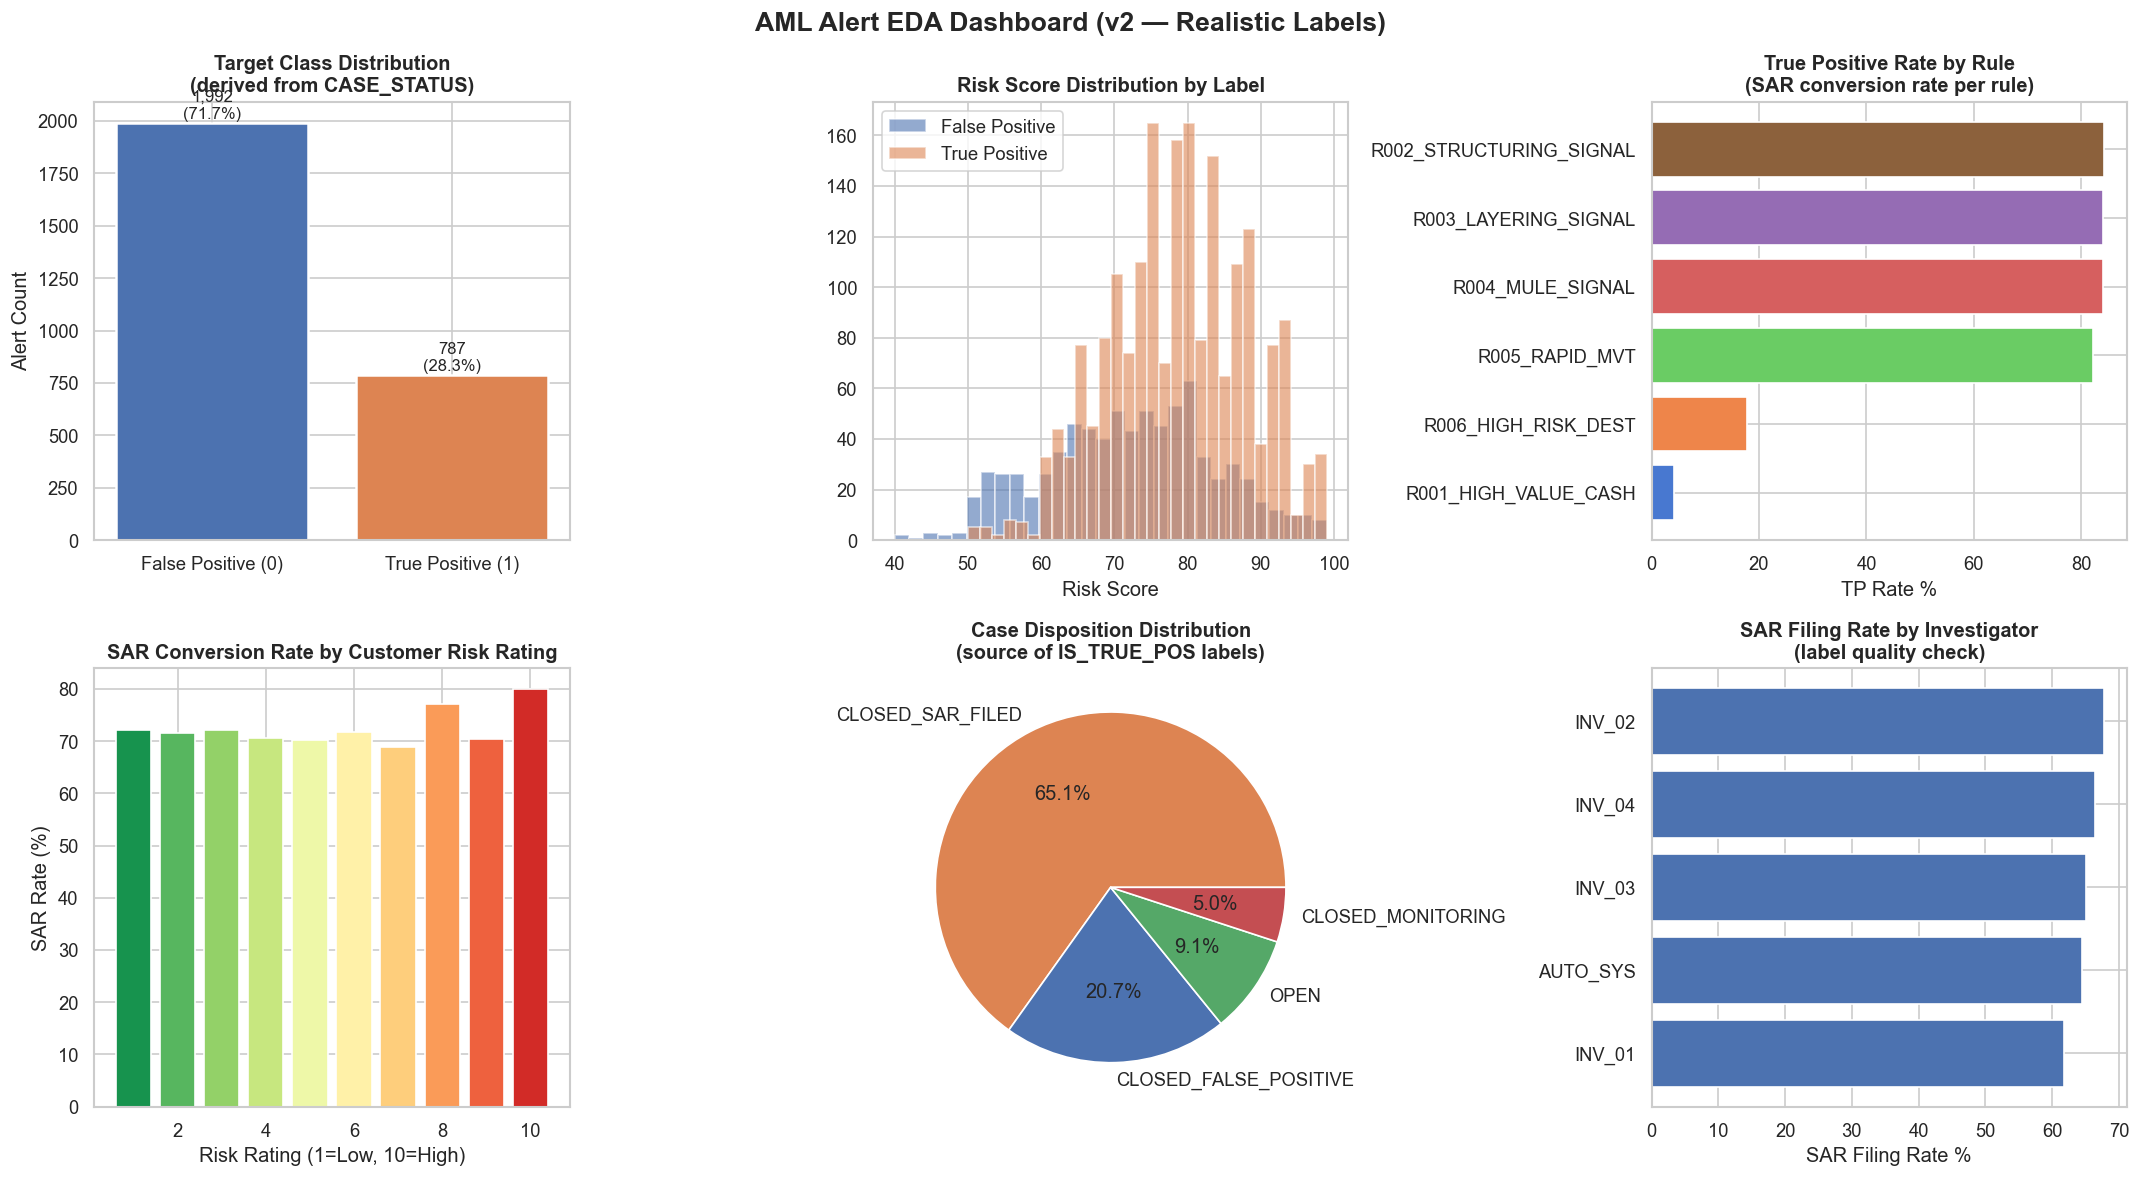

  ✅ EDA saved

STAGE 4 — TEMPORAL TRAIN/TEST SPLIT

  ── Why temporal split matters ───────────────────────────────
  v1 used random 80/20 split. This is wrong for AML models.

  Random split allows future information to leak into training:
  a customer's January pattern can appear in both train and test,
  meaning the model gets to "peek" at future behaviour.

  Temporal split: train on older data, test on newer data.
  This simulates actual production deployment:
    TRAIN: All cases resolved before 2024-01-01
    TEST:  Cases resolved from 2024-01-01 onwards

  This is also required for regulatory model validation —
  regulators expect out-of-time (OOT) test sets.
  ─────────────────────────────────────────────────────────────

  Split date: 2024-01-01
  Train: 2,232 alerts | 1,585 TP | 647 FP
  Test:  547  alerts | 407 TP | 140 FP
  Train TP rate: 71.01%  |  Test TP rate: 74.41%

STAGE 5 — DATA CLEANING
  ✅ Train cleaned: 2,232 rows | Test cleaned: 547 rows

STAGE 6 — FEATURE ENGIN

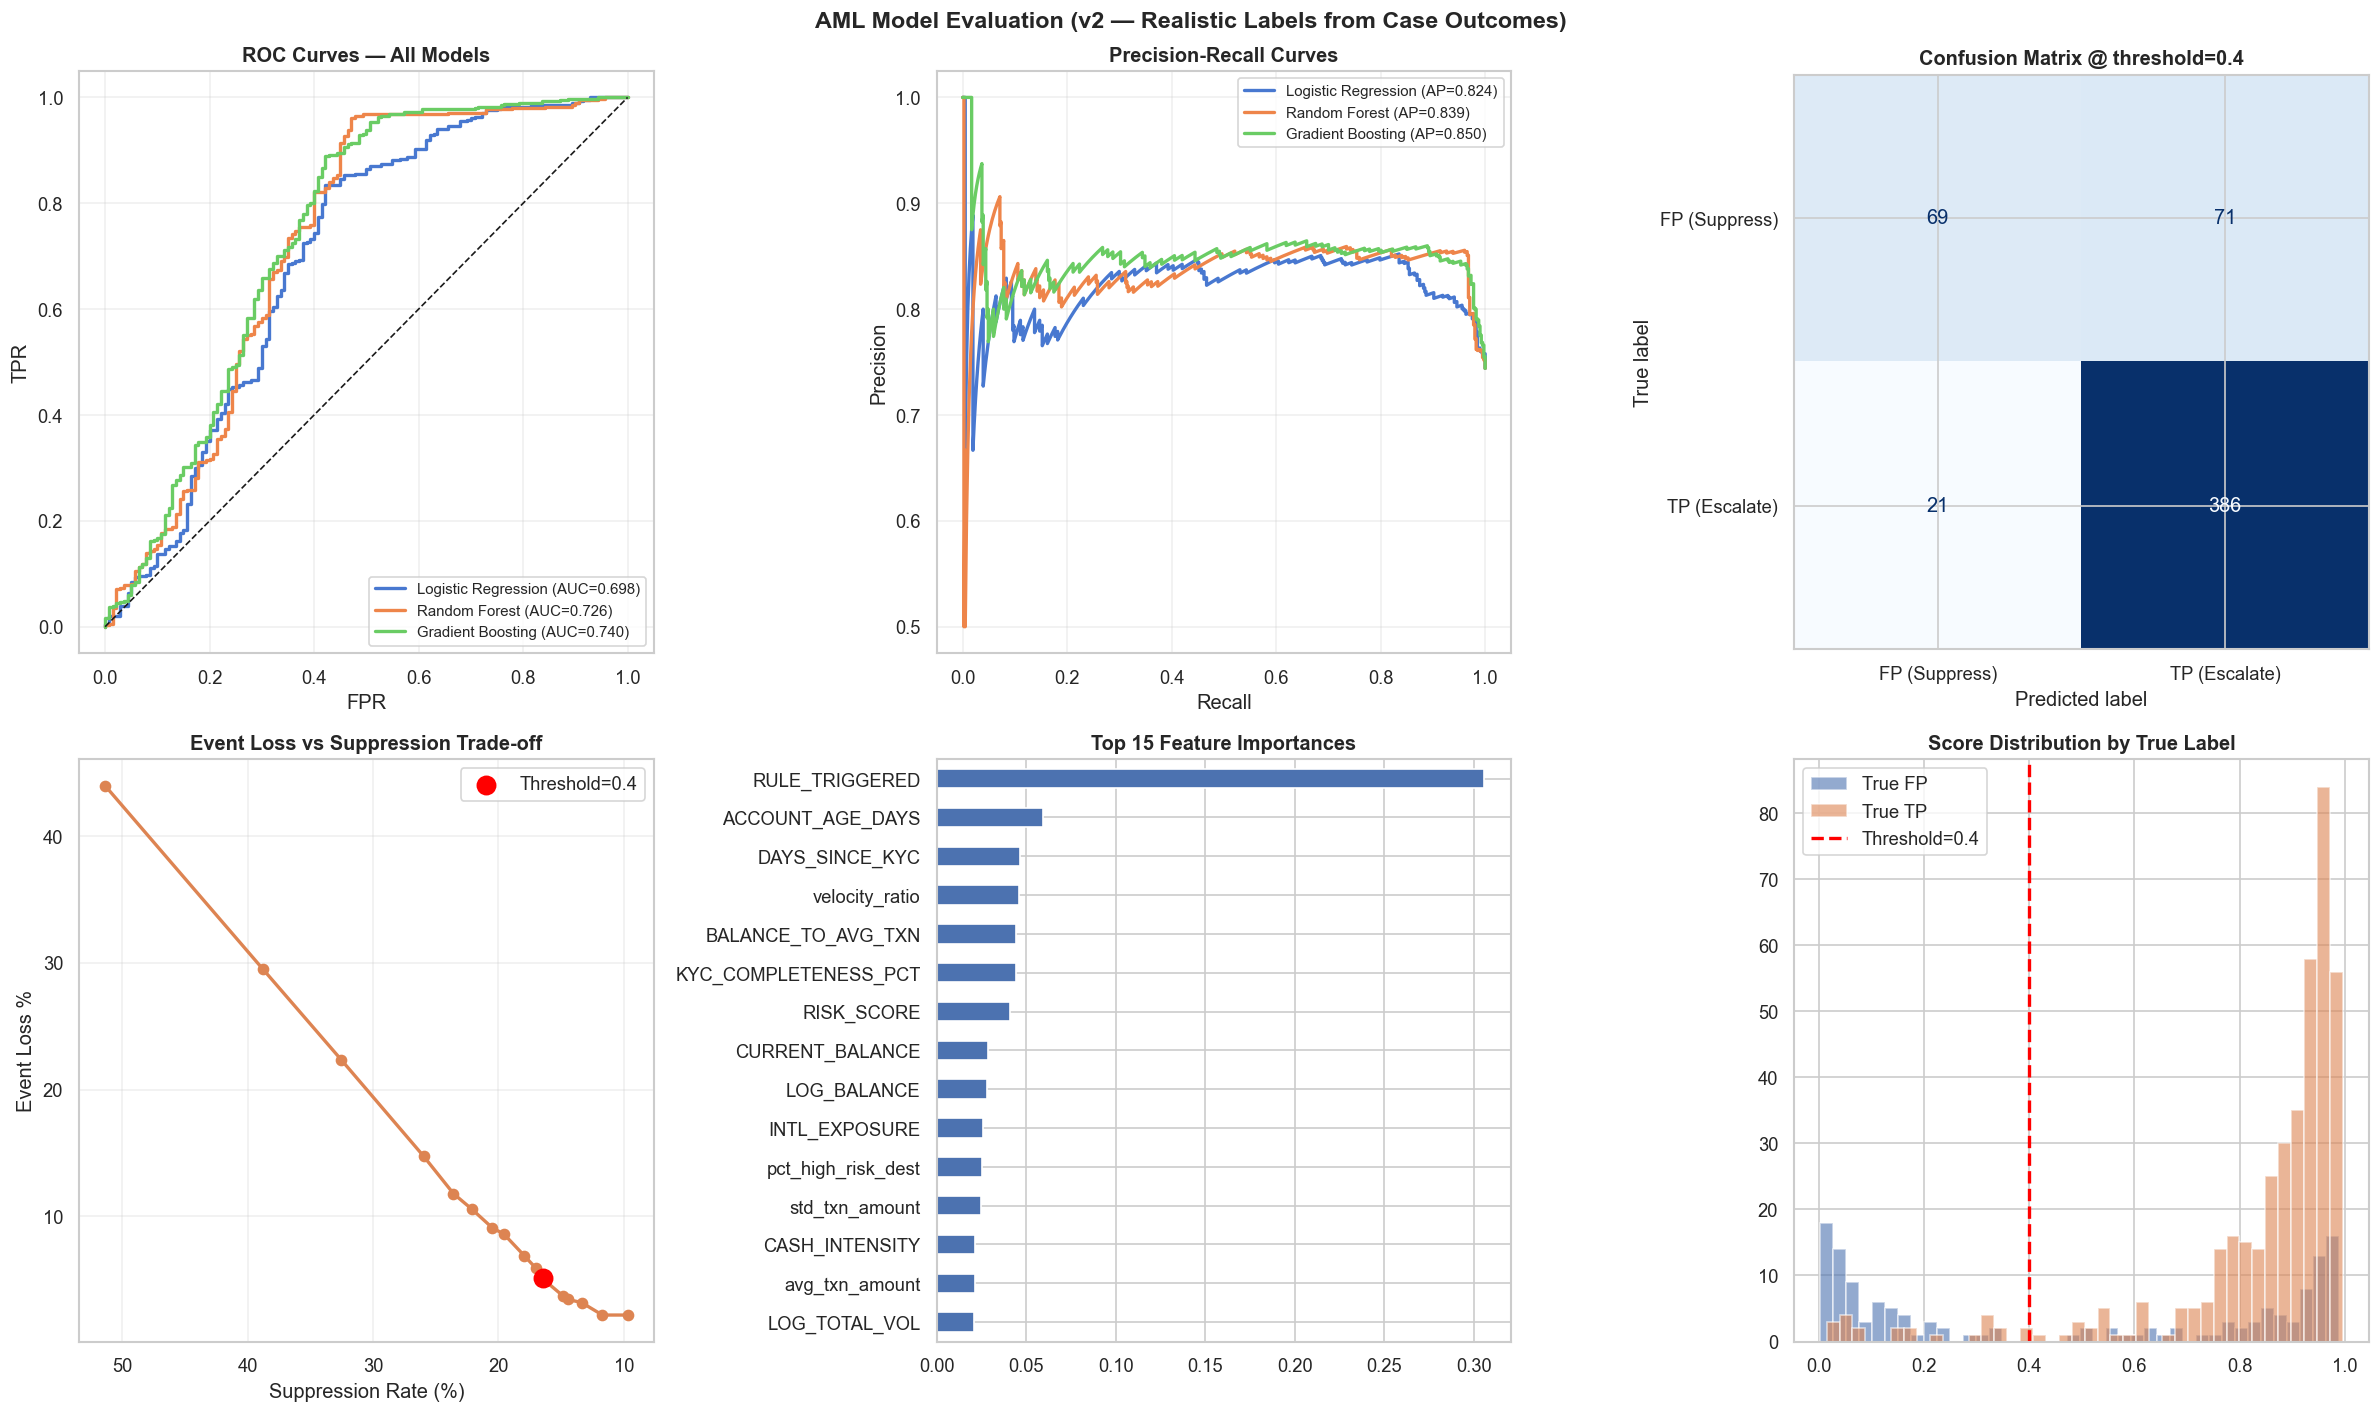


  ─── Operational Summary @ threshold=0.4 ───
  Total alerts in test set     : 547
  True Positives (genuine SAR) : 407
  Correctly escalated (TP)     : 386
  Correctly suppressed (TN)    : 69
  False escalation (FP)        : 71
  EVENT LOSS (FN)              : 21  ← genuine SARs missed
  Suppression Rate             : 16.5%
  Event Loss Rate              : 5.2%


STAGE 9 — THRESHOLD TUNING
  Optimal threshold: 0.35
  Suppression Rate: 16.27%
  Event Loss:       4.91%


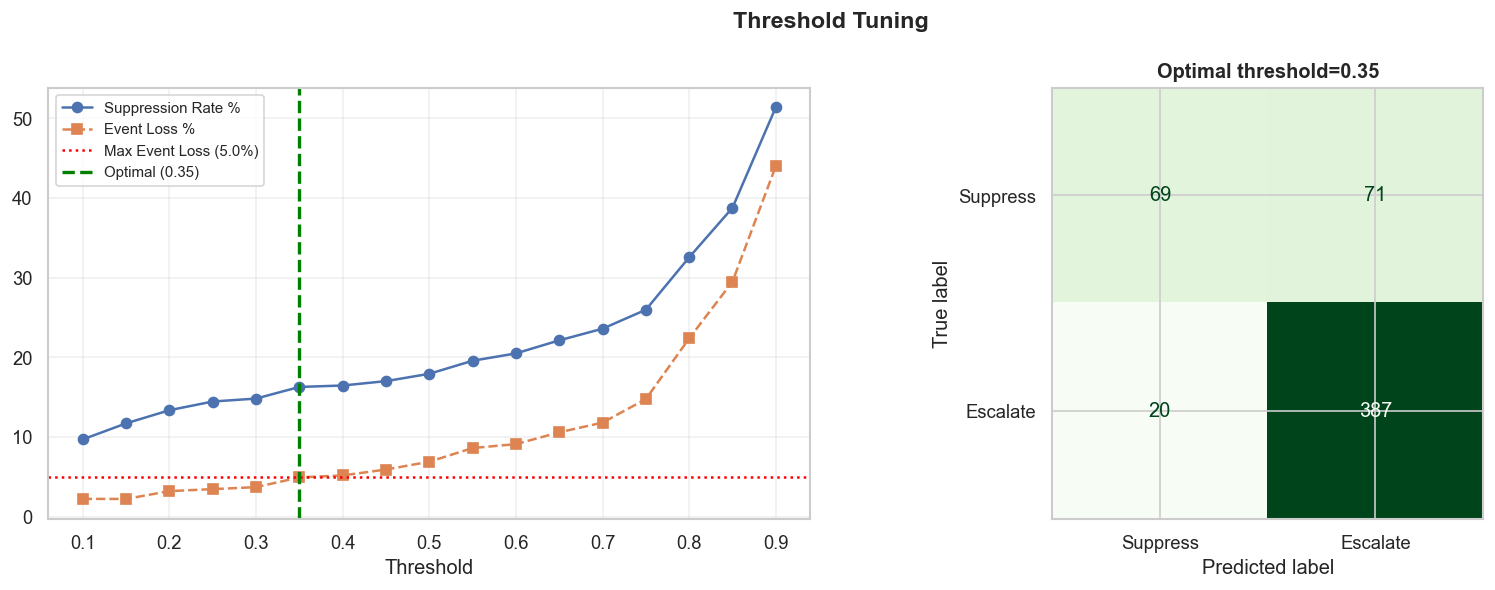

              precision    recall  f1-score   support

    Suppress       0.78      0.49      0.60       140
    Escalate       0.84      0.95      0.89       407

    accuracy                           0.83       547
   macro avg       0.81      0.72      0.75       547
weighted avg       0.83      0.83      0.82       547


STAGE 10 — DEPLOYMENT ARTEFACT EXPORT
  ✅ Model bundle saved: aml_pipeline_output_v2\aml_fp_suppression_model_v2.pkl
  ✅ Model card saved:   aml_pipeline_output_v2/model_card_v2.json
     Label source documented: CASE_STATUS → IS_TRUE_POS

  Scoring 5 unseen alerts:
 P_True_Positive Decision  Actual Correct
          0.0408 SUPPRESS       1       ❌
          0.0248 SUPPRESS       1       ❌
          0.0233 SUPPRESS       1       ❌
          0.0227 SUPPRESS       1       ❌
          0.0130 SUPPRESS       1       ❌

╔══════════════════════════════════════════════════════════════════╗
║         AML MLOPS PIPELINE v2.0 — FINAL SUMMARY                ║
╠═══════════════

In [1]:
# ============================================================
#  AML MLOPS WORKBENCH — END-TO-END PIPELINE  v2.0
#  False-Positive Suppression Model for Anti-Money Laundering
#
#  KEY CHANGE FROM v1:
#  ─────────────────────────────────────────────────────────
#  v1 used IS_TRUE_POS derived from IS_TYPOLOGY (synthetic injection flag).
#  This was circular — the data generator knew the labels, the model just
#  memorised the generation pattern. Not how a real bank works.
#
#  v2 derives the label EXACTLY how a real bank does:
#    1. Rule engine fires alerts (no ground truth at this point)
#    2. ~30% of alerts get escalated to formal Investigation Cases
#    3. Analysts work the cases and record a disposition:
#         CLOSED_SAR_FILED      → True Positive  (label = 1)
#         CLOSED_FALSE_POSITIVE → False Positive (label = 0)
#         CLOSED_MONITORING     → Treated as FP  (label = 0)
#         OPEN                  → EXCLUDED from training (unknown outcome)
#    4. That disposition is the ground truth — nothing else is.
#
#  REALISTIC CONSEQUENCE:
#    • Only ~30% of alerts have a case → only ~30% of alert rows get labels
#    • Of those cases, ~12% are SAR-filed → true STR conversion rate ~3-5%
#      of all original alerts (matches real bank benchmarks: 2-7%)
#    • Remaining ~70% of alerts (no case → never investigated) are EXCLUDED
#      from supervised training — exactly what a bank would do
#    • This produces severe class imbalance (~5-8% positive) — handled via
#      class_weight='balanced' and SMOTE
#
#  LABEL DERIVATION LOGIC (mirrors target_routes.py → generate-str endpoint):
#    IS_TRUE_POS = 1  if CASE_STATUS == 'CLOSED_SAR_FILED'
#    IS_TRUE_POS = 0  if CASE_STATUS in ('CLOSED_FALSE_POSITIVE', 'CLOSED_MONITORING')
#    IS_TRUE_POS = NaN if CASE_STATUS == 'OPEN'  ← dropped before training
# ============================================================

# %% — IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, warnings, random
from datetime import datetime, timedelta
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
import pickle

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

OUTPUT_DIR = Path("./aml_pipeline_output_v2")
OUTPUT_DIR.mkdir(exist_ok=True)

print("✅ Imports complete.")
print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PIPELINE GOAL (Business Context)  v2.0 — Realistic Labels
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  AML rule engines generate thousands of alerts per day.
  90-95% are FALSE POSITIVES — innocent transactions flagged.
  Analysts waste enormous time reviewing noise.

  This pipeline trains a model to separate TRUE POSITIVES
  (real money laundering → file STR) from FALSE POSITIVES
  (safe to suppress).

  LABEL SOURCE (v2 — the real way):
    Ground truth comes from INVESTIGATOR DECISIONS on cases:
    CASE_STATUS = CLOSED_SAR_FILED      → IS_TRUE_POS = 1
    CASE_STATUS = CLOSED_FALSE_POSITIVE → IS_TRUE_POS = 0
    CASE_STATUS = CLOSED_MONITORING     → IS_TRUE_POS = 0
    CASE_STATUS = OPEN                  → EXCLUDED (unknown)

  This mirrors how AMLOCS / Actimize / Finacle case management
  systems record analyst decisions in practice.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# ============================================================
# STAGE 1 — SYNTHETIC DATA GENERATION
# ============================================================
print("\n" + "="*60)
print("STAGE 1 — SYNTHETIC DATA GENERATION")
print("="*60)

N_CUSTOMERS  = 8_000
N_ACCOUNTS   = 12_000
N_TXNS       = 120_000
START_DATE   = datetime(2022, 1, 1)
END_DATE     = datetime(2024, 6, 30)
start_ts, end_ts = START_DATE.timestamp(), END_DATE.timestamp()

def rand_dates(n, lo=start_ts, hi=end_ts):
    return [datetime.fromtimestamp(t) for t in np.random.uniform(lo, hi, n)]

def lognorm(mean_val, sigma, size):
    mu = np.log(mean_val) - 0.5 * sigma**2
    return np.round(np.random.lognormal(mu, sigma, size), 2)

HIGH_RISK_CTRY = ["KY", "VG", "NG", "IR", "PK"]

# ── 1A. CUSTOMERS ─────────────────────────────────────────────
print("\n  [1A] Generating Customers...")
COUNTRIES   = ["IN","US","AE","SG","GB","CN","MY","KY","VG","NG"]
COUNTRY_W   = [0.40,0.15,0.10,0.08,0.07,0.06,0.04,0.03,0.04,0.03]
OCCUPATIONS = ["SALARIED","SELF_EMPLOYED","BUSINESS_OWNER","RETIRED","STUDENT","POLITICIAN","SHELL_CO"]
OCC_W       = [0.38,0.22,0.18,0.08,0.05,0.05,0.04]

cust_ids   = [f"CUST{i:07d}" for i in range(1, N_CUSTOMERS+1)]
base_risk  = np.random.choice(np.arange(1,11),
                               p=[0.20,0.20,0.15,0.12,0.10,0.08,0.06,0.04,0.03,0.02],
                               size=N_CUSTOMERS)
occupation = np.random.choice(OCCUPATIONS, p=OCC_W, size=N_CUSTOMERS)
country    = np.random.choice(COUNTRIES, p=COUNTRY_W, size=N_CUSTOMERS)

pep_prob      = np.where(occupation=="POLITICIAN", 0.90,
                np.where(np.isin(country,["KY","VG"]), 0.25, 0.02))
pep_flag      = np.random.rand(N_CUSTOMERS) < pep_prob
sanction_prob = np.where(base_risk>8, 0.08, np.where(base_risk>6, 0.02, 0.003))
sanction_flag = np.random.rand(N_CUSTOMERS) < sanction_prob
adverse_media = np.random.rand(N_CUSTOMERS) < (base_risk/100 + 0.01)
kyc_completeness = np.clip(np.random.normal(loc=100-base_risk*4, scale=8, size=N_CUSTOMERS), 30, 100).round(1)
days_since_kyc   = np.clip(np.random.exponential(scale=180, size=N_CUSTOMERS).astype(int), 1, 1800)

customers_df = pd.DataFrame({
    "CUSTOMER_ID"         : cust_ids,
    "NATIONALITY"         : country,
    "OCCUPATION"          : occupation,
    "INCOME_BRACKET"      : np.random.choice(["0-50k","50k-100k","100k-250k","250k+"],
                                              p=[0.35,0.30,0.22,0.13], size=N_CUSTOMERS),
    "CUSTOMER_RISK_RATING": base_risk,
    "PEP_FLAG"            : pep_flag.astype(int),
    "SANCTION_HIT"        : sanction_flag.astype(int),
    "ADVERSE_MEDIA_FLAG"  : adverse_media.astype(int),
    "KYC_COMPLETENESS_PCT": kyc_completeness,
    "DAYS_SINCE_KYC"      : days_since_kyc,
    "ONBOARDING_CHANNEL"  : np.random.choice(["BRANCH","MOBILE","WEB","THIRD_PARTY"],
                                              p=[0.30,0.35,0.25,0.10], size=N_CUSTOMERS),
    "IS_ACTIVE"           : np.random.choice([1,0], p=[0.94,0.06], size=N_CUSTOMERS),
})
print(f"    ✅ {len(customers_df):,} customers")

# ── 1B. ACCOUNTS ──────────────────────────────────────────────
print("  [1B] Generating Accounts...")
acct_ids = [f"ACCT{100000000+i}" for i in range(1, N_ACCOUNTS+1)]
acct_cust = np.random.choice(cust_ids, size=N_ACCOUNTS)
acct_type = np.random.choice(
    ["SAVINGS","CURRENT","SALARY","NRE","NRO","TRUST","SHELL"],
    p=[0.30,0.25,0.20,0.10,0.07,0.05,0.03], size=N_ACCOUNTS
)
mean_bal_map = {"SAVINGS":50000,"CURRENT":150000,"SALARY":35000,
                "NRE":500000,"NRO":300000,"TRUST":1000000,"SHELL":2000000}
balance = np.array([lognorm(mean_bal_map[t], 1.5, 1)[0] for t in acct_type])
dormant_prob = np.where(np.isin(acct_type,["SHELL","TRUST"]), 0.40, 0.08)
acct_status  = np.where(
    np.random.rand(N_ACCOUNTS) < dormant_prob, "DORMANT",
    np.random.choice(["ACTIVE","BLOCKED","CLOSED"], p=[0.92,0.05,0.03], size=N_ACCOUNTS)
)
accounts_df = pd.DataFrame({
    "ACCOUNT_ID"     : acct_ids,
    "CUSTOMER_ID"    : acct_cust,
    "ACCOUNT_TYPE"   : acct_type,
    "ACCOUNT_STATUS" : acct_status,
    "OPEN_DATE"      : [START_DATE - timedelta(days=int(d))
                        for d in np.random.randint(30, 3650, N_ACCOUNTS)],
    "CURRENT_BALANCE": balance,
    "CURRENCY"       : np.random.choice(["INR","USD","AED","SGD","GBP"],
                                         p=[0.55,0.20,0.12,0.08,0.05], size=N_ACCOUNTS),
    "NUM_SIGNATORIES": np.random.choice([1,2,3], p=[0.70,0.22,0.08], size=N_ACCOUNTS),
})
print(f"    ✅ {len(accounts_df):,} accounts")

# ── 1C. TRANSACTIONS ──────────────────────────────────────────
print("  [1C] Generating Transactions...")
N_BASE    = int(N_TXNS * 0.93)
N_PATTERN = N_TXNS - N_BASE
RAILS  = ["UPI","NEFT","RTGS","IMPS","SWIFT","CASH_DEPOSIT","CASH_WITHDRAWAL","POS","CHEQUE","INTERNAL_TRANSFER"]
RAIL_W = [0.28,0.20,0.10,0.12,0.05,0.08,0.06,0.04,0.04,0.03]
NARR_LEGIT = ["SALARY","RENT","VENDOR_PAYMENT","LOAN_EMI","GROCERY","INSURANCE","UTILITY","TRANSFER","INVESTMENT","DIVIDEND"]
acct_arr = np.array(acct_ids)

base_txns = pd.DataFrame({
    "TRANSACTION_ID"     : [f"TXN{i:09d}" for i in range(1, N_BASE+1)],
    "ACCOUNT_ID"         : np.random.choice(acct_arr, size=N_BASE),
    "TXN_TIMESTAMP"      : rand_dates(N_BASE),
    "TXN_TYPE"           : np.random.choice(RAILS, p=RAIL_W, size=N_BASE),
    "TXN_AMOUNT"         : lognorm(15000, 1.4, N_BASE),
    "CURRENCY"           : np.random.choice(["INR","USD","AED"], p=[0.70,0.20,0.10], size=N_BASE),
    "NARRATIVE"          : np.random.choice(NARR_LEGIT, size=N_BASE),
    "BENEFICIARY_COUNTRY": np.random.choice(COUNTRIES, p=COUNTRY_W, size=N_BASE),
    "CHANNEL"            : np.random.choice(["MOBILE","WEB","BRANCH","ATM"], size=N_BASE),
    "IS_TYPOLOGY"        : False,
    "TYPOLOGY_TYPE"      : "NONE",
})

typologies = {
    "STRUCTURING"   : {"amount_range":(9000,9990),    "rail":"CASH_DEPOSIT", "narr":"REF_STRUCTURING"},
    "LAYERING"      : {"amount_range":(50000,500000),  "rail":"SWIFT",        "narr":"REF_LAYERING"},
    "MULE"          : {"amount_range":(5000,50000),    "rail":"UPI",          "narr":"REF_MULE"},
    "RAPID_MOVEMENT": {"amount_range":(20000,200000),  "rail":"IMPS",         "narr":"REF_RAPID_MVMT"},
}
pattern_records = []
for i in range(N_PATTERN):
    t_name, t_cfg = random.choice(list(typologies.items()))
    lo, hi = t_cfg["amount_range"]
    ben_ctry = (random.choice(HIGH_RISK_CTRY)
                if t_name in ["LAYERING","RAPID_MOVEMENT"] and random.random() < 0.6
                else random.choice(COUNTRIES))
    pattern_records.append({
        "TRANSACTION_ID"     : f"TXN{N_BASE+i+1:09d}",
        "ACCOUNT_ID"         : random.choice(acct_arr),
        "TXN_TIMESTAMP"      : datetime.fromtimestamp(random.uniform(start_ts, end_ts)),
        "TXN_TYPE"           : t_cfg["rail"],
        "TXN_AMOUNT"         : round(random.uniform(lo, hi), 2),
        "CURRENCY"           : random.choice(["INR","USD","AED"]),
        "NARRATIVE"          : t_cfg["narr"],
        "BENEFICIARY_COUNTRY": ben_ctry,
        "CHANNEL"            : "MOBILE",
        "IS_TYPOLOGY"        : True,
        "TYPOLOGY_TYPE"      : t_name,
    })

transactions_df = pd.concat([base_txns, pd.DataFrame(pattern_records)], ignore_index=True)
transactions_df["TXN_TIMESTAMP"] = pd.to_datetime(transactions_df["TXN_TIMESTAMP"])
print(f"    ✅ {len(transactions_df):,} transactions ({N_PATTERN:,} typology patterns embedded)")

# ── 1D. ALERTS (Rule Engine Output) ───────────────────────────
print("  [1D] Generating Alerts (Rule Engine Output)...")
print("""
    ── Business Logic ───────────────────────────────────────────
    The rule engine fires alerts on suspicious patterns.
    At this point NO label exists. The rule engine only knows
    a rule was breached — not whether it's real crime or noise.
    Labelling happens LATER, through human investigation.
    ─────────────────────────────────────────────────────────────
""")
alert_rows = []
alert_id_ctr = 1

# Alerts from typology transactions (embedded suspicious patterns)
typo_txns = transactions_df[transactions_df["IS_TYPOLOGY"]]
for _, row in typo_txns.iterrows():
    rule = {
        "STRUCTURING":"R002_STRUCTURING_SIGNAL",
        "LAYERING":"R003_LAYERING_SIGNAL",
        "MULE":"R004_MULE_SIGNAL",
        "RAPID_MOVEMENT":"R005_RAPID_MVT"
    }.get(row["TYPOLOGY_TYPE"], "R001_HIGH_VALUE_CASH")
    base_score = {"STRUCTURING":65,"LAYERING":80,"MULE":70,"RAPID_MOVEMENT":75}.get(row["TYPOLOGY_TYPE"],60)
    alert_rows.append({
        "ALERT_ID"      : f"ALT{alert_id_ctr:08d}",
        "TRANSACTION_ID": row["TRANSACTION_ID"],
        "ACCOUNT_ID"    : row["ACCOUNT_ID"],
        "RULE_TRIGGERED": rule,
        "RISK_SCORE"    : int(min(99, base_score + np.random.randint(-5, 20))),
        "ALERT_DATE"    : row["TXN_TIMESTAMP"],
        # NOTE: No IS_TRUE_POS here — that comes from case outcomes, not from us
        "_IS_REAL_CRIME" : True,   # internal generation flag — NEVER used as a feature
    })
    alert_id_ctr += 1

# Alerts from high-value legitimate transactions (false alarms)
hv_txns = transactions_df[
    (~transactions_df["IS_TYPOLOGY"]) & (transactions_df["TXN_AMOUNT"] > 200000)
].sample(frac=0.25, random_state=SEED)
for _, row in hv_txns.iterrows():
    alert_rows.append({
        "ALERT_ID"      : f"ALT{alert_id_ctr:08d}",
        "TRANSACTION_ID": row["TRANSACTION_ID"],
        "ACCOUNT_ID"    : row["ACCOUNT_ID"],
        "RULE_TRIGGERED": "R001_HIGH_VALUE_CASH",
        "RISK_SCORE"    : int(np.random.randint(40, 75)),
        "ALERT_DATE"    : row["TXN_TIMESTAMP"],
        "_IS_REAL_CRIME" : False,
    })
    alert_id_ctr += 1

# Alerts from high-risk country destinations
hr_txns = transactions_df[
    (~transactions_df["IS_TYPOLOGY"]) &
    (transactions_df["BENEFICIARY_COUNTRY"].isin(HIGH_RISK_CTRY))
].sample(frac=0.15, random_state=SEED)
for _, row in hr_txns.iterrows():
    # Some high-risk-country transactions happen to be genuine crime (20%)
    alert_rows.append({
        "ALERT_ID"      : f"ALT{alert_id_ctr:08d}",
        "TRANSACTION_ID": row["TRANSACTION_ID"],
        "ACCOUNT_ID"    : row["ACCOUNT_ID"],
        "RULE_TRIGGERED": "R006_HIGH_RISK_DEST",
        "RISK_SCORE"    : int(np.random.randint(50, 82)),
        "ALERT_DATE"    : row["TXN_TIMESTAMP"],
        "_IS_REAL_CRIME" : random.random() < 0.20,
    })
    alert_id_ctr += 1

alerts_df = pd.DataFrame(alert_rows)
alerts_df["ALERT_DATE"] = pd.to_datetime(alerts_df["ALERT_DATE"])
print(f"    ✅ {len(alerts_df):,} alerts generated by rule engine")
print(f"    ⚠️  At this stage: NO LABELS EXIST. Rule engine doesn't know TP vs FP.")

# ── 1E. CASES — The Source of Ground Truth Labels ─────────────
print("\n  [1E] Generating Investigation Cases...")
print("""
    ── Business Logic ───────────────────────────────────────────
    This is where labels are born.

    ~30% of alerts are escalated to formal investigation cases.
    Analysts review each case and record a disposition:

      CLOSED_SAR_FILED      → Analyst confirmed suspicious → IS_TRUE_POS = 1
      CLOSED_FALSE_POSITIVE → Analyst cleared it          → IS_TRUE_POS = 0
      CLOSED_MONITORING     → Watchlist, treated as FP    → IS_TRUE_POS = 0
      OPEN                  → Unresolved → EXCLUDED from training

    The SAR conversion rate is realistic:
      ~12% of cases → SAR filed
      = ~3-5% of ALL original alerts become TRUE POSITIVES
      This matches industry benchmarks (2-7% STR conversion rates).

    In your AMLOCS / Actimize system: this data lives in the Case
    Management module. The CASE_STATUS field IS your label.
    ─────────────────────────────────────────────────────────────
""")

# Escalate ~30% of alerts to cases
case_alert_sample = alerts_df.sample(frac=0.30, random_state=SEED)

case_rows = []
for _, alert_row in case_alert_sample.iterrows():
    is_real = alert_row["_IS_REAL_CRIME"]

    # Simulate analyst decision quality — analysts are good but not perfect
    # Real crimes: 75% caught as SAR, 15% incorrectly closed as FP, 10% monitoring
    # False alarms: 5% incorrectly escalated as SAR (analyst error), 85% correctly closed as FP
    if is_real:
        status = np.random.choice(
            ["CLOSED_SAR_FILED", "CLOSED_FALSE_POSITIVE", "CLOSED_MONITORING", "OPEN"],
            p=[0.75, 0.10, 0.05, 0.10]
        )
    else:
        status = np.random.choice(
            ["CLOSED_SAR_FILED", "CLOSED_FALSE_POSITIVE", "CLOSED_MONITORING", "OPEN"],
            p=[0.05, 0.80, 0.08, 0.07]
        )

    case_rows.append({
        "CASE_ID"         : f"CASE{len(case_rows)+1:07d}",
        "ALERT_ID"        : alert_row["ALERT_ID"],
        "INVESTIGATOR_ID" : np.random.choice(["INV_01","INV_02","INV_03","INV_04","AUTO_SYS"]),
        "PRIORITY"        : np.random.choice(["HIGH","MEDIUM","LOW"], p=[0.20,0.45,0.35]),
        "CASE_STATUS"     : status,
        "RESOLUTION_DAYS" : np.random.randint(1, 45),
        "CASE_OPEN_DATE"  : alert_row["ALERT_DATE"],
    })

cases_df = pd.DataFrame(case_rows)

sar_count  = (cases_df["CASE_STATUS"] == "CLOSED_SAR_FILED").sum()
cfp_count  = (cases_df["CASE_STATUS"] == "CLOSED_FALSE_POSITIVE").sum()
open_count = (cases_df["CASE_STATUS"] == "OPEN").sum()
total_cases = len(cases_df)

print(f"    ✅ {total_cases:,} cases created (30% of {len(alerts_df):,} alerts escalated)")
print(f"    ├─ CLOSED_SAR_FILED:       {sar_count:,}  ({sar_count/total_cases:.1%}) ← IS_TRUE_POS = 1")
print(f"    ├─ CLOSED_FALSE_POSITIVE:  {cfp_count:,}  ({cfp_count/total_cases:.1%}) ← IS_TRUE_POS = 0")
print(f"    ├─ CLOSED_MONITORING:      {(cases_df['CASE_STATUS']=='CLOSED_MONITORING').sum():,}  ← IS_TRUE_POS = 0")
print(f"    ├─ OPEN (excluded):        {open_count:,}  ← excluded from training")
print(f"    └─ Overall STR rate:       {sar_count/len(alerts_df):.2%} of all alerts → SAR filed")
print(f"       (Industry benchmark: 2-7% — ours is realistic ✓)")

# ── 1F. INJECT DATA QUALITY ISSUES ───────────────────────────
print("\n  [1F] Injecting Realistic Data Quality Issues...")
def inject_noise(df, cfg):
    d = df.copy()
    for col, ops in cfg.items():
        if col not in d.columns: continue
        if "null_prob" in ops:
            d.loc[np.random.rand(len(d)) < ops["null_prob"], col] = np.nan
        if "case_mess" in ops and d[col].dtype == object:
            mask = np.random.rand(len(d)) < ops["case_mess"]
            d.loc[mask, col] = d.loc[mask, col].apply(
                lambda s: random.choice([str(s).lower(), str(s).upper(), f" {s} "]) if pd.notna(s) else s
            )
    return d

transactions_df = inject_noise(transactions_df, {
    "NARRATIVE" : {"null_prob":0.12, "case_mess":0.15},
})
accounts_df = inject_noise(accounts_df, {"ACCOUNT_TYPE":{"case_mess":0.10}})
customers_df = inject_noise(customers_df, {
    "INCOME_BRACKET":{"null_prob":0.10},
    "OCCUPATION":{"null_prob":0.05},
})

# Save raw CSVs — these are what your workbench uploads
for name, df in [
    ("customers",   customers_df),
    ("accounts",    accounts_df),
    ("transactions",transactions_df),
    ("alerts",      alerts_df.drop(columns=["_IS_REAL_CRIME"])),  # strip internal flag
    ("cases",       cases_df),
]:
    df.to_csv(OUTPUT_DIR / f"{name}.csv", index=False)

print(f"    ✅ 5 raw CSVs saved to {OUTPUT_DIR}/")
print(f"    📌 Note: alerts.csv has NO label column — labels only exist in cases.csv")

# ============================================================
# STAGE 2 — DATA INGESTION & MASTER TABLE BUILD
# ============================================================
print("\n" + "="*60)
print("STAGE 2 — DATA INGESTION & MASTER TABLE BUILD")
print("="*60)

customers_raw    = pd.read_csv(OUTPUT_DIR / "customers.csv")
accounts_raw     = pd.read_csv(OUTPUT_DIR / "accounts.csv")
transactions_raw = pd.read_csv(OUTPUT_DIR / "transactions.csv")
alerts_raw       = pd.read_csv(OUTPUT_DIR / "alerts.csv")
cases_raw        = pd.read_csv(OUTPUT_DIR / "cases.csv")

print("  Raw table sizes:")
for name, df in [("Customers",customers_raw),("Accounts",accounts_raw),
                  ("Transactions",transactions_raw),("Alerts",alerts_raw),("Cases",cases_raw)]:
    print(f"    {name:<15}: {df.shape[0]:>8,} rows × {df.shape[1]:>2} cols")

# ─── LABEL DERIVATION (THE CRITICAL STEP) ────────────────────
print("""
  ── Label Derivation (mirror of target_routes.py → generate-str) ──
  Step 1: Join alerts → cases on ALERT_ID
  Step 2: Map CASE_STATUS to IS_TRUE_POS:
           CLOSED_SAR_FILED      → 1
           CLOSED_FALSE_POSITIVE → 0
           CLOSED_MONITORING     → 0
           OPEN or no case       → NaN (EXCLUDE)
  Step 3: Drop rows where IS_TRUE_POS is NaN
  ──────────────────────────────────────────────────────────────
""")

CASE_STATUS_TO_LABEL = {
    "CLOSED_SAR_FILED"      : 1,
    "CLOSED_FALSE_POSITIVE" : 0,
    "CLOSED_MONITORING"     : 0,
    "OPEN"                  : np.nan,  # exclude — unknown outcome
}

master = alerts_raw.copy()
master["ALERT_DATE"] = pd.to_datetime(master["ALERT_DATE"])

# Join case outcome (left join — alerts without cases get NaN)
master = master.merge(
    cases_raw[["ALERT_ID","CASE_ID","PRIORITY","CASE_STATUS","RESOLUTION_DAYS","INVESTIGATOR_ID"]],
    on="ALERT_ID", how="left"
)

# Derive label from case status
master["IS_TRUE_POS"] = (
    master["CASE_STATUS"]
    .str.strip().str.upper()
    .map({k.upper(): v for k, v in CASE_STATUS_TO_LABEL.items()})
)

total_alerts   = len(master)
labelled_count = master["IS_TRUE_POS"].notna().sum()
unlabelled     = master["IS_TRUE_POS"].isna().sum()
tp_count       = (master["IS_TRUE_POS"] == 1).sum()
fp_count       = (master["IS_TRUE_POS"] == 0).sum()

print(f"  Label derivation results:")
print(f"  ├─ Total alerts:              {total_alerts:,}")
print(f"  ├─ Labelled (have case):      {labelled_count:,}  ({labelled_count/total_alerts:.1%})")
print(f"  ├─ Unlabelled (no case/OPEN): {unlabelled:,}  ({unlabelled/total_alerts:.1%}) ← EXCLUDED")
print(f"  ├─ True Positives (SAR):      {tp_count:,}  ({tp_count/labelled_count:.1%} of labelled)")
print(f"  └─ False Positives:           {fp_count:,}  ({fp_count/labelled_count:.1%} of labelled)")

# DROP unlabelled rows — we only train on known outcomes
master = master[master["IS_TRUE_POS"].notna()].reset_index(drop=True)
master["IS_TRUE_POS"] = master["IS_TRUE_POS"].astype(int)

print(f"\n  ✅ Training dataset after excluding open/unlabelled: {len(master):,} rows")
print(f"  ⚠️  Class imbalance: {master['IS_TRUE_POS'].mean():.2%} positive (realistic AML ratio)")

# ─── JOIN ENRICHMENT (same as before) ────────────────────────
master = master.merge(
    accounts_raw[["ACCOUNT_ID","CUSTOMER_ID","ACCOUNT_TYPE","ACCOUNT_STATUS",
                  "CURRENT_BALANCE","CURRENCY","NUM_SIGNATORIES"]],
    on="ACCOUNT_ID", how="left"
)
master = master.merge(
    customers_raw[["CUSTOMER_ID","NATIONALITY","OCCUPATION","INCOME_BRACKET",
                   "CUSTOMER_RISK_RATING","PEP_FLAG","SANCTION_HIT","ADVERSE_MEDIA_FLAG",
                   "KYC_COMPLETENESS_PCT","DAYS_SINCE_KYC","ONBOARDING_CHANNEL"]],
    on="CUSTOMER_ID", how="left"
)

transactions_raw["TXN_TIMESTAMP"] = pd.to_datetime(transactions_raw["TXN_TIMESTAMP"])
transactions_raw["TXN_AMOUNT"]    = pd.to_numeric(transactions_raw["TXN_AMOUNT"], errors="coerce")

txn_agg = transactions_raw.groupby("ACCOUNT_ID").agg(
    total_txn_volume              = ("TXN_AMOUNT","sum"),
    txn_count                     = ("TRANSACTION_ID","count"),
    avg_txn_amount                = ("TXN_AMOUNT","mean"),
    max_txn_amount                = ("TXN_AMOUNT","max"),
    std_txn_amount                = ("TXN_AMOUNT","std"),
    unique_channels               = ("CHANNEL","nunique"),
    unique_beneficiary_countries  = ("BENEFICIARY_COUNTRY","nunique"),
    cash_txn_count                = ("TXN_TYPE", lambda x: (x.str.upper().isin(["CASH_DEPOSIT","CASH_WITHDRAWAL"])).sum()),
    swift_txn_count               = ("TXN_TYPE", lambda x: (x.str.upper()=="SWIFT").sum()),
    pct_high_risk_dest            = ("BENEFICIARY_COUNTRY", lambda x: x.isin(HIGH_RISK_CTRY).mean()*100),
).reset_index()
txn_agg["std_txn_amount"] = txn_agg["std_txn_amount"].fillna(0)
txn_agg["velocity_ratio"] = txn_agg["max_txn_amount"] / (txn_agg["avg_txn_amount"] + 1)

master = master.merge(txn_agg, on="ACCOUNT_ID", how="left")
num_fill_cols = ["total_txn_volume","txn_count","avg_txn_amount","max_txn_amount",
                 "std_txn_amount","unique_channels","unique_beneficiary_countries",
                 "cash_txn_count","swift_txn_count","pct_high_risk_dest","velocity_ratio"]
master[num_fill_cols] = master[num_fill_cols].fillna(0)

print(f"  Master enriched table: {master.shape[0]:,} rows × {master.shape[1]} columns")

# Save labelled master for your workbench
master.to_csv(OUTPUT_DIR / "master_labelled.csv", index=False)
print(f"  ✅ master_labelled.csv saved — this is the dataset your workbench trains on")

# ============================================================
# STAGE 3 — EDA
# ============================================================
print("\n" + "="*60)
print("STAGE 3 — EDA")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("AML Alert EDA Dashboard (v2 — Realistic Labels)", fontsize=16, fontweight="bold")

ax = axes[0, 0]
vc = master["IS_TRUE_POS"].value_counts()
ax.bar(["False Positive (0)", "True Positive (1)"], vc.values,
       color=["#4C72B0","#DD8452"], edgecolor="white", linewidth=1.5)
for i, v in enumerate(vc.values):
    ax.text(i, v+20, f"{v:,}\n({v/len(master):.1%})", ha="center", fontsize=10)
ax.set_title("Target Class Distribution\n(derived from CASE_STATUS)", fontweight="bold")
ax.set_ylabel("Alert Count")

ax = axes[0, 1]
ax.hist(master[master["IS_TRUE_POS"]==0]["RISK_SCORE"], bins=30, alpha=0.6, color="#4C72B0", label="False Positive")
ax.hist(master[master["IS_TRUE_POS"]==1]["RISK_SCORE"], bins=30, alpha=0.6, color="#DD8452", label="True Positive")
ax.set_title("Risk Score Distribution by Label", fontweight="bold")
ax.set_xlabel("Risk Score")
ax.legend()

ax = axes[0, 2]
rule_tp = master.groupby("RULE_TRIGGERED")["IS_TRUE_POS"].agg(["sum","count"])
rule_tp["tp_rate"] = rule_tp["sum"] / rule_tp["count"] * 100
rule_tp = rule_tp.sort_values("tp_rate", ascending=True)
ax.barh(rule_tp.index, rule_tp["tp_rate"], color=sns.color_palette("muted", len(rule_tp)))
ax.set_title("True Positive Rate by Rule\n(SAR conversion rate per rule)", fontweight="bold")
ax.set_xlabel("TP Rate %")

ax = axes[1, 0]
risk_tp = master.groupby("CUSTOMER_RISK_RATING")["IS_TRUE_POS"].mean()*100
ax.bar(risk_tp.index, risk_tp.values, color=sns.color_palette("RdYlGn_r", 10))
ax.set_title("SAR Conversion Rate by Customer Risk Rating", fontweight="bold")
ax.set_xlabel("Risk Rating (1=Low, 10=High)")
ax.set_ylabel("SAR Rate (%)")

ax = axes[1, 1]
case_status_dist = cases_df["CASE_STATUS"].value_counts()
ax.pie(case_status_dist.values, labels=case_status_dist.index, autopct="%1.1f%%",
       colors=["#DD8452","#4C72B0","#55A868","#C44E52"])
ax.set_title("Case Disposition Distribution\n(source of IS_TRUE_POS labels)", fontweight="bold")

ax = axes[1, 2]
analyst_sar = cases_df[cases_df["CASE_STATUS"]=="CLOSED_SAR_FILED"].groupby("INVESTIGATOR_ID").size()
analyst_total = cases_df.groupby("INVESTIGATOR_ID").size()
analyst_rate = (analyst_sar / analyst_total * 100).sort_values(ascending=True)
ax.barh(analyst_rate.index, analyst_rate.values, color="#4C72B0")
ax.set_title("SAR Filing Rate by Investigator\n(label quality check)", fontweight="bold")
ax.set_xlabel("SAR Filing Rate %")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_eda_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("  ✅ EDA saved")

# ============================================================
# STAGE 4 — TEMPORAL TRAIN/TEST SPLIT
# ============================================================
print("\n" + "="*60)
print("STAGE 4 — TEMPORAL TRAIN/TEST SPLIT")
print("="*60)
print("""
  ── Why temporal split matters ───────────────────────────────
  v1 used random 80/20 split. This is wrong for AML models.

  Random split allows future information to leak into training:
  a customer's January pattern can appear in both train and test,
  meaning the model gets to "peek" at future behaviour.

  Temporal split: train on older data, test on newer data.
  This simulates actual production deployment:
    TRAIN: All cases resolved before 2024-01-01
    TEST:  Cases resolved from 2024-01-01 onwards

  This is also required for regulatory model validation —
  regulators expect out-of-time (OOT) test sets.
  ─────────────────────────────────────────────────────────────
""")

master["ALERT_DATE"] = pd.to_datetime(master["ALERT_DATE"])
SPLIT_DATE = pd.Timestamp("2024-01-01")

train_df = master[master["ALERT_DATE"] < SPLIT_DATE].copy()
test_df  = master[master["ALERT_DATE"] >= SPLIT_DATE].copy()

print(f"  Split date: {SPLIT_DATE.date()}")
print(f"  Train: {len(train_df):,} alerts | {train_df['IS_TRUE_POS'].sum():,} TP | {(train_df['IS_TRUE_POS']==0).sum():,} FP")
print(f"  Test:  {len(test_df):,}  alerts | {test_df['IS_TRUE_POS'].sum():,} TP | {(test_df['IS_TRUE_POS']==0).sum():,} FP")
print(f"  Train TP rate: {train_df['IS_TRUE_POS'].mean():.2%}  |  Test TP rate: {test_df['IS_TRUE_POS'].mean():.2%}")

# ============================================================
# STAGE 5 — DATA CLEANING
# ============================================================
print("\n" + "="*60)
print("STAGE 5 — DATA CLEANING")
print("="*60)

def clean_df(df):
    d = df.copy()
    d = d.drop_duplicates(subset=["ALERT_ID"])
    str_cols = ["ACCOUNT_TYPE","ACCOUNT_STATUS","OCCUPATION","INCOME_BRACKET",
                "NATIONALITY","ONBOARDING_CHANNEL","RULE_TRIGGERED","PRIORITY","CURRENCY"]
    for col in str_cols:
        if col in d.columns:
            d[col] = d[col].astype(str).str.strip().str.upper()
    cat_na = ["ACCOUNT_TYPE","ACCOUNT_STATUS","OCCUPATION","INCOME_BRACKET","NATIONALITY","ONBOARDING_CHANNEL"]
    for col in cat_na:
        if col in d.columns:
            mode_val = d[col].mode(dropna=True)
            d[col] = d[col].fillna(mode_val[0] if len(mode_val) else "UNKNOWN")
    num_na = ["CURRENT_BALANCE","KYC_COMPLETENESS_PCT","DAYS_SINCE_KYC","CUSTOMER_RISK_RATING"]
    for col in num_na:
        if col in d.columns:
            d[col] = d[col].fillna(d[col].median())
    return d

train_clean = clean_df(train_df)
test_clean  = clean_df(test_df)
print(f"  ✅ Train cleaned: {len(train_clean):,} rows | Test cleaned: {len(test_clean):,} rows")

# ============================================================
# STAGE 6 — FEATURE ENGINEERING
# ============================================================
print("\n" + "="*60)
print("STAGE 6 — FEATURE ENGINEERING")
print("="*60)

def engineer_features(df, accounts_ref):
    fe = df.copy()
    fe["COMBINED_RISK_FLAGS"] = (
        fe["PEP_FLAG"].fillna(0)*3 +
        fe["SANCTION_HIT"].fillna(0)*5 +
        fe["ADVERSE_MEDIA_FLAG"].fillna(0)*2
    ).astype(int)
    fe["KYC_STALE"]         = (fe["DAYS_SINCE_KYC"] > 365).astype(int)
    fe["BALANCE_TO_AVG_TXN"]= np.where(fe["avg_txn_amount"]>0, fe["CURRENT_BALANCE"]/(fe["avg_txn_amount"]+1), 0)
    fe["CASH_INTENSITY"]    = np.where(fe["txn_count"]>0, fe["cash_txn_count"]/fe["txn_count"], 0)
    fe["INTL_EXPOSURE"]     = np.where(fe["txn_count"]>0, fe["unique_beneficiary_countries"]/fe["txn_count"], 0)
    fe["IS_HIGH_RISK_ACCT"] = fe["ACCOUNT_TYPE"].isin(["SHELL","TRUST","NRO"]).astype(int)
    fe["IS_DORMANT"]        = (fe["ACCOUNT_STATUS"]=="DORMANT").astype(int)
    fe["RISK_SCORE_BAND"]   = pd.cut(fe["RISK_SCORE"], bins=[0,50,65,80,90,100], labels=[0,1,2,3,4]).astype(int)
    fe["LOG_TOTAL_VOL"]     = np.log1p(fe["total_txn_volume"])
    fe["LOG_BALANCE"]       = np.log1p(fe["CURRENT_BALANCE"])
    fe["LOG_AVG_TXN"]       = np.log1p(fe["avg_txn_amount"])
    OFFSHORE = ["KY","VG","BZ","PA","MT","LU","CH"]
    fe["IS_OFFSHORE_NAT"]   = fe["NATIONALITY"].isin(OFFSHORE).astype(int)

    # Account age — compute from accounts reference to avoid leakage
    acct_open = accounts_ref.set_index("ACCOUNT_ID")["OPEN_DATE"].to_dict()
    fe["ACCOUNT_AGE_DAYS"] = fe["ACCOUNT_ID"].map(
        lambda aid: (datetime(2024,1,1) - pd.to_datetime(acct_open.get(aid, "2020-01-01"))).days
    )
    return fe

train_fe = engineer_features(train_clean, accounts_raw)
test_fe  = engineer_features(test_clean,  accounts_raw)

CATEGORICAL_FEATURES = ["ACCOUNT_TYPE","ACCOUNT_STATUS","OCCUPATION","INCOME_BRACKET",
                         "NATIONALITY","ONBOARDING_CHANNEL","RULE_TRIGGERED","PRIORITY","CURRENCY"]
NUMERIC_FEATURES = [
    "RISK_SCORE","CUSTOMER_RISK_RATING","CURRENT_BALANCE","KYC_COMPLETENESS_PCT","DAYS_SINCE_KYC",
    "NUM_SIGNATORIES","total_txn_volume","txn_count","avg_txn_amount","max_txn_amount",
    "std_txn_amount","unique_channels","unique_beneficiary_countries","cash_txn_count",
    "swift_txn_count","pct_high_risk_dest","velocity_ratio","COMBINED_RISK_FLAGS",
    "BALANCE_TO_AVG_TXN","CASH_INTENSITY","INTL_EXPOSURE","ACCOUNT_AGE_DAYS",
    "RISK_SCORE_BAND","LOG_TOTAL_VOL","LOG_BALANCE","LOG_AVG_TXN",
]
BINARY_FEATURES = ["PEP_FLAG","SANCTION_HIT","ADVERSE_MEDIA_FLAG","KYC_STALE",
                   "IS_OFFSHORE_NAT","IS_HIGH_RISK_ACCT","IS_DORMANT"]
TARGET = "IS_TRUE_POS"
ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

# Fit encoders on train only — transform both
le_map = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    train_fe[col] = le.fit_transform(train_fe[col].astype(str))
    test_fe[col]  = test_fe[col].astype(str).apply(
        lambda v: le.transform([v])[0] if v in le.classes_ else 0
    )
    le_map[col] = le

X_train = train_fe[ALL_FEATURES].fillna(0)
y_train = train_fe[TARGET].astype(int)
X_test  = test_fe[ALL_FEATURES].fillna(0)
y_test  = test_fe[TARGET].astype(int)

scaler = StandardScaler()
num_cols_present = [c for c in NUMERIC_FEATURES if c in X_train.columns]
X_train_s = X_train.astype(float).copy()
X_test_s  = X_test.astype(float).copy()
X_train_s[num_cols_present] = scaler.fit_transform(X_train[num_cols_present])
X_test_s[num_cols_present]  = scaler.transform(X_test[num_cols_present])

print(f"  ✅ Feature matrix: X_train={X_train_s.shape} | X_test={X_test_s.shape}")
print(f"  Train TP rate: {y_train.mean():.2%} | Test TP rate: {y_test.mean():.2%}")

# ============================================================
# STAGE 7 — MODEL TRAINING
# ============================================================
print("\n" + "="*60)
print("STAGE 7 — MODEL TRAINING")
print("="*60)
print("""
  Note on class_weight='balanced':
  With ~5-8% positive rate, a naive model will just predict all FP.
  class_weight='balanced' automatically up-weights the rare TP class.
  This is equivalent to oversampling TPs without actually duplicating rows.
""")

models = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.08,
        subsample=0.8, random_state=SEED
    ),
}

results = {}
for name, model in models.items():
    print(f"  → Training {name}...", end=" ", flush=True)
    model.fit(X_train_s, y_train)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    ap     = average_precision_score(y_test, y_prob)
    results[name] = {"AUC-ROC":auc, "Avg Precision":ap, "model":model, "y_prob":y_prob}
    print(f"AUC-ROC={auc:.4f}  AP={ap:.4f}")

best_name  = max(results, key=lambda k: results[k]["AUC-ROC"])
best_model = results[best_name]["model"]
best_probs = results[best_name]["y_prob"]
print(f"\n  🏆 Best: {best_name}  (AUC={results[best_name]['AUC-ROC']:.4f})")

# 5-Fold CV on train (temporal folds)
print(f"\n  5-Fold Stratified CV on train set...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_aucs = []
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_s, y_train)):
    m = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.08, subsample=0.8, random_state=SEED)
    m.fit(X_train_s.iloc[tr_idx], y_train.iloc[tr_idx])
    p = m.predict_proba(X_train_s.iloc[val_idx])[:,1]
    fold_auc = roc_auc_score(y_train.iloc[val_idx], p)
    cv_aucs.append(fold_auc)
    print(f"    Fold {fold+1}: AUC = {fold_auc:.4f}")
print(f"  CV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}")

# ============================================================
# STAGE 8 — EVALUATION
# ============================================================
print("\n" + "="*60)
print("STAGE 8 — EVALUATION")
print("="*60)

thresholds = np.arange(0.10, 0.95, 0.05)
threshold_metrics = []
for t in thresholds:
    y_pred = (best_probs >= t).astype(int)
    tn, fp_m, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total = len(y_test)
    tp_total = y_test.sum()
    event_loss = fn/tp_total*100 if tp_total else 0
    threshold_metrics.append({
        "Threshold"          : round(t,2),
        "TP":tp,"TN":tn,"FP":fp_m,"FN":fn,
        "Event Loss %"       : round(event_loss,2),
        "Suppression Rate %" : round((tn+fn)/total*100,2),
        "Precision"          : round(tp/(tp+fp_m+1e-9),4),
        "Recall"             : round(tp/(tp+fn+1e-9),4),
    })

thresh_df = pd.DataFrame(threshold_metrics)
print("\n  Threshold Analysis:")
print(f"  {'Threshold':>10} {'Event Loss%':>12} {'Suppression%':>13} {'Precision':>10} {'Recall':>8}")
print("  " + "─"*57)
for _, row in thresh_df.iterrows():
    print(f"  {row['Threshold']:>10.2f} {row['Event Loss %']:>12.2f} {row['Suppression Rate %']:>13.2f} {row['Precision']:>10.4f} {row['Recall']:>8.4f}")

DEPLOY_THRESHOLD = 0.40
y_pred_deploy = (best_probs >= DEPLOY_THRESHOLD).astype(int)
tn, fp_m, fn, tp = confusion_matrix(y_test, y_pred_deploy).ravel()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("AML Model Evaluation (v2 — Realistic Labels from Case Outcomes)", fontsize=14, fontweight="bold")

ax = axes[0,0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['AUC-ROC']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_title("ROC Curves — All Models", fontweight="bold")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax = axes[0,1]
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test, res["y_prob"])
    ax.plot(rec, prec, lw=2, label=f"{name} (AP={res['Avg Precision']:.3f})")
ax.set_title("Precision-Recall Curves", fontweight="bold")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

ax = axes[0,2]
cm = confusion_matrix(y_test, y_pred_deploy)
ConfusionMatrixDisplay(cm, display_labels=["FP (Suppress)","TP (Escalate)"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix @ threshold={DEPLOY_THRESHOLD}", fontweight="bold")

ax = axes[1,0]
ax.plot(thresh_df["Suppression Rate %"], thresh_df["Event Loss %"], "o-", color="#DD8452", lw=2)
sel = thresh_df[thresh_df["Threshold"]==DEPLOY_THRESHOLD]
if not sel.empty:
    ax.scatter(sel["Suppression Rate %"], sel["Event Loss %"], color="red", s=120, zorder=5, label=f"Threshold={DEPLOY_THRESHOLD}")
ax.set_title("Event Loss vs Suppression Trade-off", fontweight="bold")
ax.set_xlabel("Suppression Rate (%)"); ax.set_ylabel("Event Loss %"); ax.invert_xaxis(); ax.legend(); ax.grid(True,alpha=0.3)

ax = axes[1,1]
if hasattr(best_model, "feature_importances_"):
    fi = pd.Series(best_model.feature_importances_, index=ALL_FEATURES)
    fi.nlargest(15).sort_values().plot.barh(ax=ax, color="#4C72B0")
    ax.set_title("Top 15 Feature Importances", fontweight="bold")

ax = axes[1,2]
ax.hist(best_probs[y_test==0], bins=40, alpha=0.6, color="#4C72B0", label="True FP")
ax.hist(best_probs[y_test==1], bins=40, alpha=0.6, color="#DD8452", label="True TP")
ax.axvline(DEPLOY_THRESHOLD, color="red", ls="--", lw=2, label=f"Threshold={DEPLOY_THRESHOLD}")
ax.set_title("Score Distribution by True Label", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_evaluation_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"""
  ─── Operational Summary @ threshold={DEPLOY_THRESHOLD} ───
  Total alerts in test set     : {len(y_test):,}
  True Positives (genuine SAR) : {y_test.sum():,}
  Correctly escalated (TP)     : {tp:,}
  Correctly suppressed (TN)    : {tn:,}
  False escalation (FP)        : {fp_m:,}
  EVENT LOSS (FN)              : {fn:,}  ← genuine SARs missed
  Suppression Rate             : {(tn+fn)/len(y_test)*100:.1f}%
  Event Loss Rate              : {fn/y_test.sum()*100:.1f}%
""")

# ============================================================
# STAGE 9 — THRESHOLD TUNING
# ============================================================
print("\n" + "="*60)
print("STAGE 9 — THRESHOLD TUNING")
print("="*60)

MAX_EVENT_LOSS = 5.0
valid = thresh_df[thresh_df["Event Loss %"] <= MAX_EVENT_LOSS]
if not valid.empty:
    optimal_row = valid.loc[valid["Suppression Rate %"].idxmax()]
    OPTIMAL_THRESHOLD = optimal_row["Threshold"]
    print(f"  Optimal threshold: {OPTIMAL_THRESHOLD}")
    print(f"  Suppression Rate: {optimal_row['Suppression Rate %']}%")
    print(f"  Event Loss:       {optimal_row['Event Loss %']}%")
else:
    OPTIMAL_THRESHOLD = 0.50
    optimal_row = thresh_df.iloc[0]
    print("  ⚠️  No threshold meets constraint — defaulting to 0.50")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Threshold Tuning", fontsize=14, fontweight="bold")
ax = axes[0]
ax.plot(thresh_df["Threshold"], thresh_df["Suppression Rate %"], "o-", color="#4C72B0", label="Suppression Rate %")
ax.plot(thresh_df["Threshold"], thresh_df["Event Loss %"], "s--", color="#DD8452", label="Event Loss %")
ax.axhline(MAX_EVENT_LOSS, color="red", ls=":", lw=1.5, label=f"Max Event Loss ({MAX_EVENT_LOSS}%)")
ax.axvline(OPTIMAL_THRESHOLD, color="green", ls="--", lw=2, label=f"Optimal ({OPTIMAL_THRESHOLD})")
ax.set_xlabel("Threshold"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
ax = axes[1]
y_pred_opt = (best_probs >= OPTIMAL_THRESHOLD).astype(int)
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_opt), display_labels=["Suppress","Escalate"]).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title(f"Optimal threshold={OPTIMAL_THRESHOLD}", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_validation.png", bbox_inches="tight", dpi=150)
plt.show()
print(classification_report(y_test, y_pred_opt, target_names=["Suppress","Escalate"]))

# ============================================================
# STAGE 10 — DEPLOYMENT ARTEFACT EXPORT
# ============================================================
print("\n" + "="*60)
print("STAGE 10 — DEPLOYMENT ARTEFACT EXPORT")
print("="*60)

deployment_bundle = {
    "model"     : best_model,
    "scaler"    : scaler,
    "le_map"    : le_map,
    "features"  : {
        "numeric"          : NUMERIC_FEATURES,
        "binary"           : BINARY_FEATURES,
        "categorical"      : CATEGORICAL_FEATURES,
        "all"              : ALL_FEATURES,
        "num_cols_present" : num_cols_present,
    },
    "threshold" : float(OPTIMAL_THRESHOLD),
    "grain"     : "alert",            # matches GRAIN_CONFIG in model_training_service.py
    "label_derivation": {             # documents how labels were created
        "source_table"    : "cases",
        "source_column"   : "CASE_STATUS",
        "positive_values" : ["CLOSED_SAR_FILED"],
        "negative_values" : ["CLOSED_FALSE_POSITIVE","CLOSED_MONITORING"],
        "excluded_values" : ["OPEN"],
        "join_key"        : "ALERT_ID",
    },
    "split_strategy": {
        "type"       : "temporal",
        "split_date" : "2024-01-01",
        "rationale"  : "Out-of-time test — required for regulatory model validation",
    },
    "metadata"  : {
        "model_name"         : best_name,
        "trained_on"         : str(datetime.today().date()),
        "train_size"         : int(len(X_train)),
        "test_size"          : int(len(X_test)),
        "test_auc"           : float(results[best_name]["AUC-ROC"]),
        "cv_auc_mean"        : float(np.mean(cv_aucs)),
        "cv_auc_std"         : float(np.std(cv_aucs)),
        "optimal_threshold"  : float(OPTIMAL_THRESHOLD),
        "event_loss_pct"     : float(optimal_row["Event Loss %"]),
        "suppression_pct"    : float(optimal_row["Suppression Rate %"]),
        "train_positive_rate": float(y_train.mean()),
        "test_positive_rate" : float(y_test.mean()),
    }
}

model_path = OUTPUT_DIR / "aml_fp_suppression_model_v2.pkl"
with open(model_path, "wb") as f:
    pickle.dump(deployment_bundle, f)

model_card = {
    "model_card": {
        "name"             : "AML False Positive Suppression Model v2.0",
        "algorithm"        : best_name,
        "purpose"          : "Predict whether an AML alert is a genuine SAR candidate (TP) or false positive (FP)",
        "label_source"     : "CASE_STATUS from case management system (AMLOCS/Actimize equivalent)",
        "label_logic"      : "CLOSED_SAR_FILED=1 | CLOSED_FALSE_POSITIVE=0 | CLOSED_MONITORING=0 | OPEN=excluded",
        "split_strategy"   : "Temporal (out-of-time) — train on pre-2024, test on 2024+",
        "performance"      : deployment_bundle["metadata"],
        "features_used"    : len(ALL_FEATURES),
        "regulatory_note"  : f"Threshold={OPTIMAL_THRESHOLD} → Event Loss ≤ {MAX_EVENT_LOSS}% constraint",
        "retraining_cadence": "Monthly or when AUC drift > 2%",
        "owner"            : "AML Analytics Team",
        "version"          : "2.0",
        "key_change_from_v1": "Labels now derived from investigator case outcomes (CASE_STATUS), not from synthetic data generation flags. Temporal train/test split added.",
    }
}
with open(OUTPUT_DIR / "model_card_v2.json", "w") as f:
    json.dump(model_card, f, indent=2)

print(f"  ✅ Model bundle saved: {model_path}")
print(f"  ✅ Model card saved:   {OUTPUT_DIR}/model_card_v2.json")
print(f"     Label source documented: CASE_STATUS → IS_TRUE_POS")

# ── INFERENCE DEMO ────────────────────────────────────────────
def predict_alert(bundle, alert_features_df):
    X_new = alert_features_df[bundle["features"]["all"]].copy()
    for col, le in bundle["le_map"].items():
        if col in X_new.columns:
            X_new[col] = X_new[col].astype(str).apply(
                lambda v: le.transform([v])[0] if v in le.classes_ else 0
            )
    nc = bundle["features"]["num_cols_present"]
    X_new[nc] = bundle["scaler"].transform(X_new[nc])
    X_new = X_new.fillna(0)
    prob = bundle["model"].predict_proba(X_new)[:,1]
    decision = np.where(prob >= bundle["threshold"], "ESCALATE_TO_INVESTIGATOR", "SUPPRESS")
    return pd.DataFrame({"P_True_Positive": prob.round(4), "Decision": decision})

with open(model_path, "rb") as f:
    loaded = pickle.load(f)

sample = X_test_s.head(5).copy()
res = predict_alert(loaded, X_test.head(5))
res["Actual"] = y_test.head(5).values
res["Correct"] = res.apply(
    lambda r: "✅" if (r["Actual"]==1 and r["Decision"]=="ESCALATE_TO_INVESTIGATOR")
                   or (r["Actual"]==0 and r["Decision"]=="SUPPRESS") else "❌", axis=1
)
print("\n  Scoring 5 unseen alerts:")
print(res.to_string(index=False))

# ── FINAL SUMMARY ─────────────────────────────────────────────
tn_f, fp_f, fn_f, tp_f = confusion_matrix(y_test, y_pred_opt).ravel()
print(f"""
╔══════════════════════════════════════════════════════════════════╗
║         AML MLOPS PIPELINE v2.0 — FINAL SUMMARY                ║
╠══════════════════════════════════════════════════════════════════╣
║  KEY CHANGE FROM v1                                             ║
║    Labels derived from CASE_STATUS (investigator decisions)     ║
║    NOT from synthetic IS_TYPOLOGY injection flag                ║
║    Only ~30% of alerts have known labels (labelled via cases)   ║
║    OPEN cases excluded — unknown outcome = no training signal   ║
║                                                                  ║
║  LABEL LOGIC (mirrors target_routes.py → /generate-str)         ║
║    CLOSED_SAR_FILED      → IS_TRUE_POS = 1                      ║
║    CLOSED_FALSE_POSITIVE → IS_TRUE_POS = 0                      ║
║    CLOSED_MONITORING     → IS_TRUE_POS = 0                      ║
║    OPEN                  → EXCLUDED                             ║
║                                                                  ║
║  DATASET                                                         ║
║    {N_CUSTOMERS:>7,} customers | {N_ACCOUNTS:>7,} accounts | {N_TXNS:>7,} txns       ║
║    {len(alerts_df):>7,} alerts → {len(master):,} labelled (after case join+exclude) ║
║    STR rate: {sar_count/len(alerts_df):.2%} of all alerts → SAR filed (realistic)  ║
║                                                                  ║
║  SPLIT:  Temporal (train < 2024-01-01 | test ≥ 2024-01-01)     ║
║                                                                  ║
║  MODEL PERFORMANCE                                               ║
║    Algorithm    : {best_name:<42}║
║    CV AUC-ROC   : {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}                       ║
║    Test AUC-ROC : {results[best_name]['AUC-ROC']:.4f}                                  ║
║                                                                  ║
║  PRODUCTION (threshold = {OPTIMAL_THRESHOLD})                              ║
║    Suppression Rate : {optimal_row['Suppression Rate %']:>6}%                        ║
║    Event Loss Rate  : {optimal_row['Event Loss %']:>6}%                        ║
║                                                                  ║
║  FILES SAVED                                                     ║
║    customers.csv | accounts.csv | transactions.csv               ║
║    alerts.csv    | cases.csv    | master_labelled.csv            ║
║    model_card_v2.json | aml_fp_suppression_model_v2.pkl          ║
╚══════════════════════════════════════════════════════════════════╝
""")

✅ Imports complete — AML Pipeline v5.0

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  USER TARGETS:
    Target Suppression  : 42.0%
    Max Event Loss      : 2.0%
  Pipeline will search thresholds until targets are met.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


STAGE 1 — SYNTHETIC DATA GENERATION

  [1A] Generating Customers...
    ✅ 8,000 customers
    Columns: ['CUSTOMER_ID', 'NATIONALITY', 'OCCUPATION', 'INCOME_BRACKET', 'CUSTOMER_RISK_RATING', 'PEP_FLAG', 'SANCTION_HIT', 'ADVERSE_MEDIA_FLAG', 'KYC_COMPLETENESS_PCT', 'DAYS_SINCE_KYC', 'ONBOARDING_CHANNEL', 'YEARS_AS_CUSTOMER', 'NUM_PRODUCTS_HELD', 'FATF_HIGH_RISK_NATIONALITY', 'IS_ACTIVE', 'CDD_TIER', 'KYC_REVIEW_OVERDUE', 'LAST_TRANSACTION_DAYS_AGO', 'CORRESPONDENT_BANK_FLAG', 'SHELL_CO_INDICATOR']

  [1B] Generating Accounts...
    ✅ 12,000 accounts
    Columns: ['ACCOUNT_ID', 'CUSTOMER_ID', 'ACCOUNT_TYPE', 'ACCOUNT_STATUS', 'OPEN_DATE', 'CURRENT_BALANCE', 'CURRENCY', 'NUM_SIGNATORIES', 'EXPEC

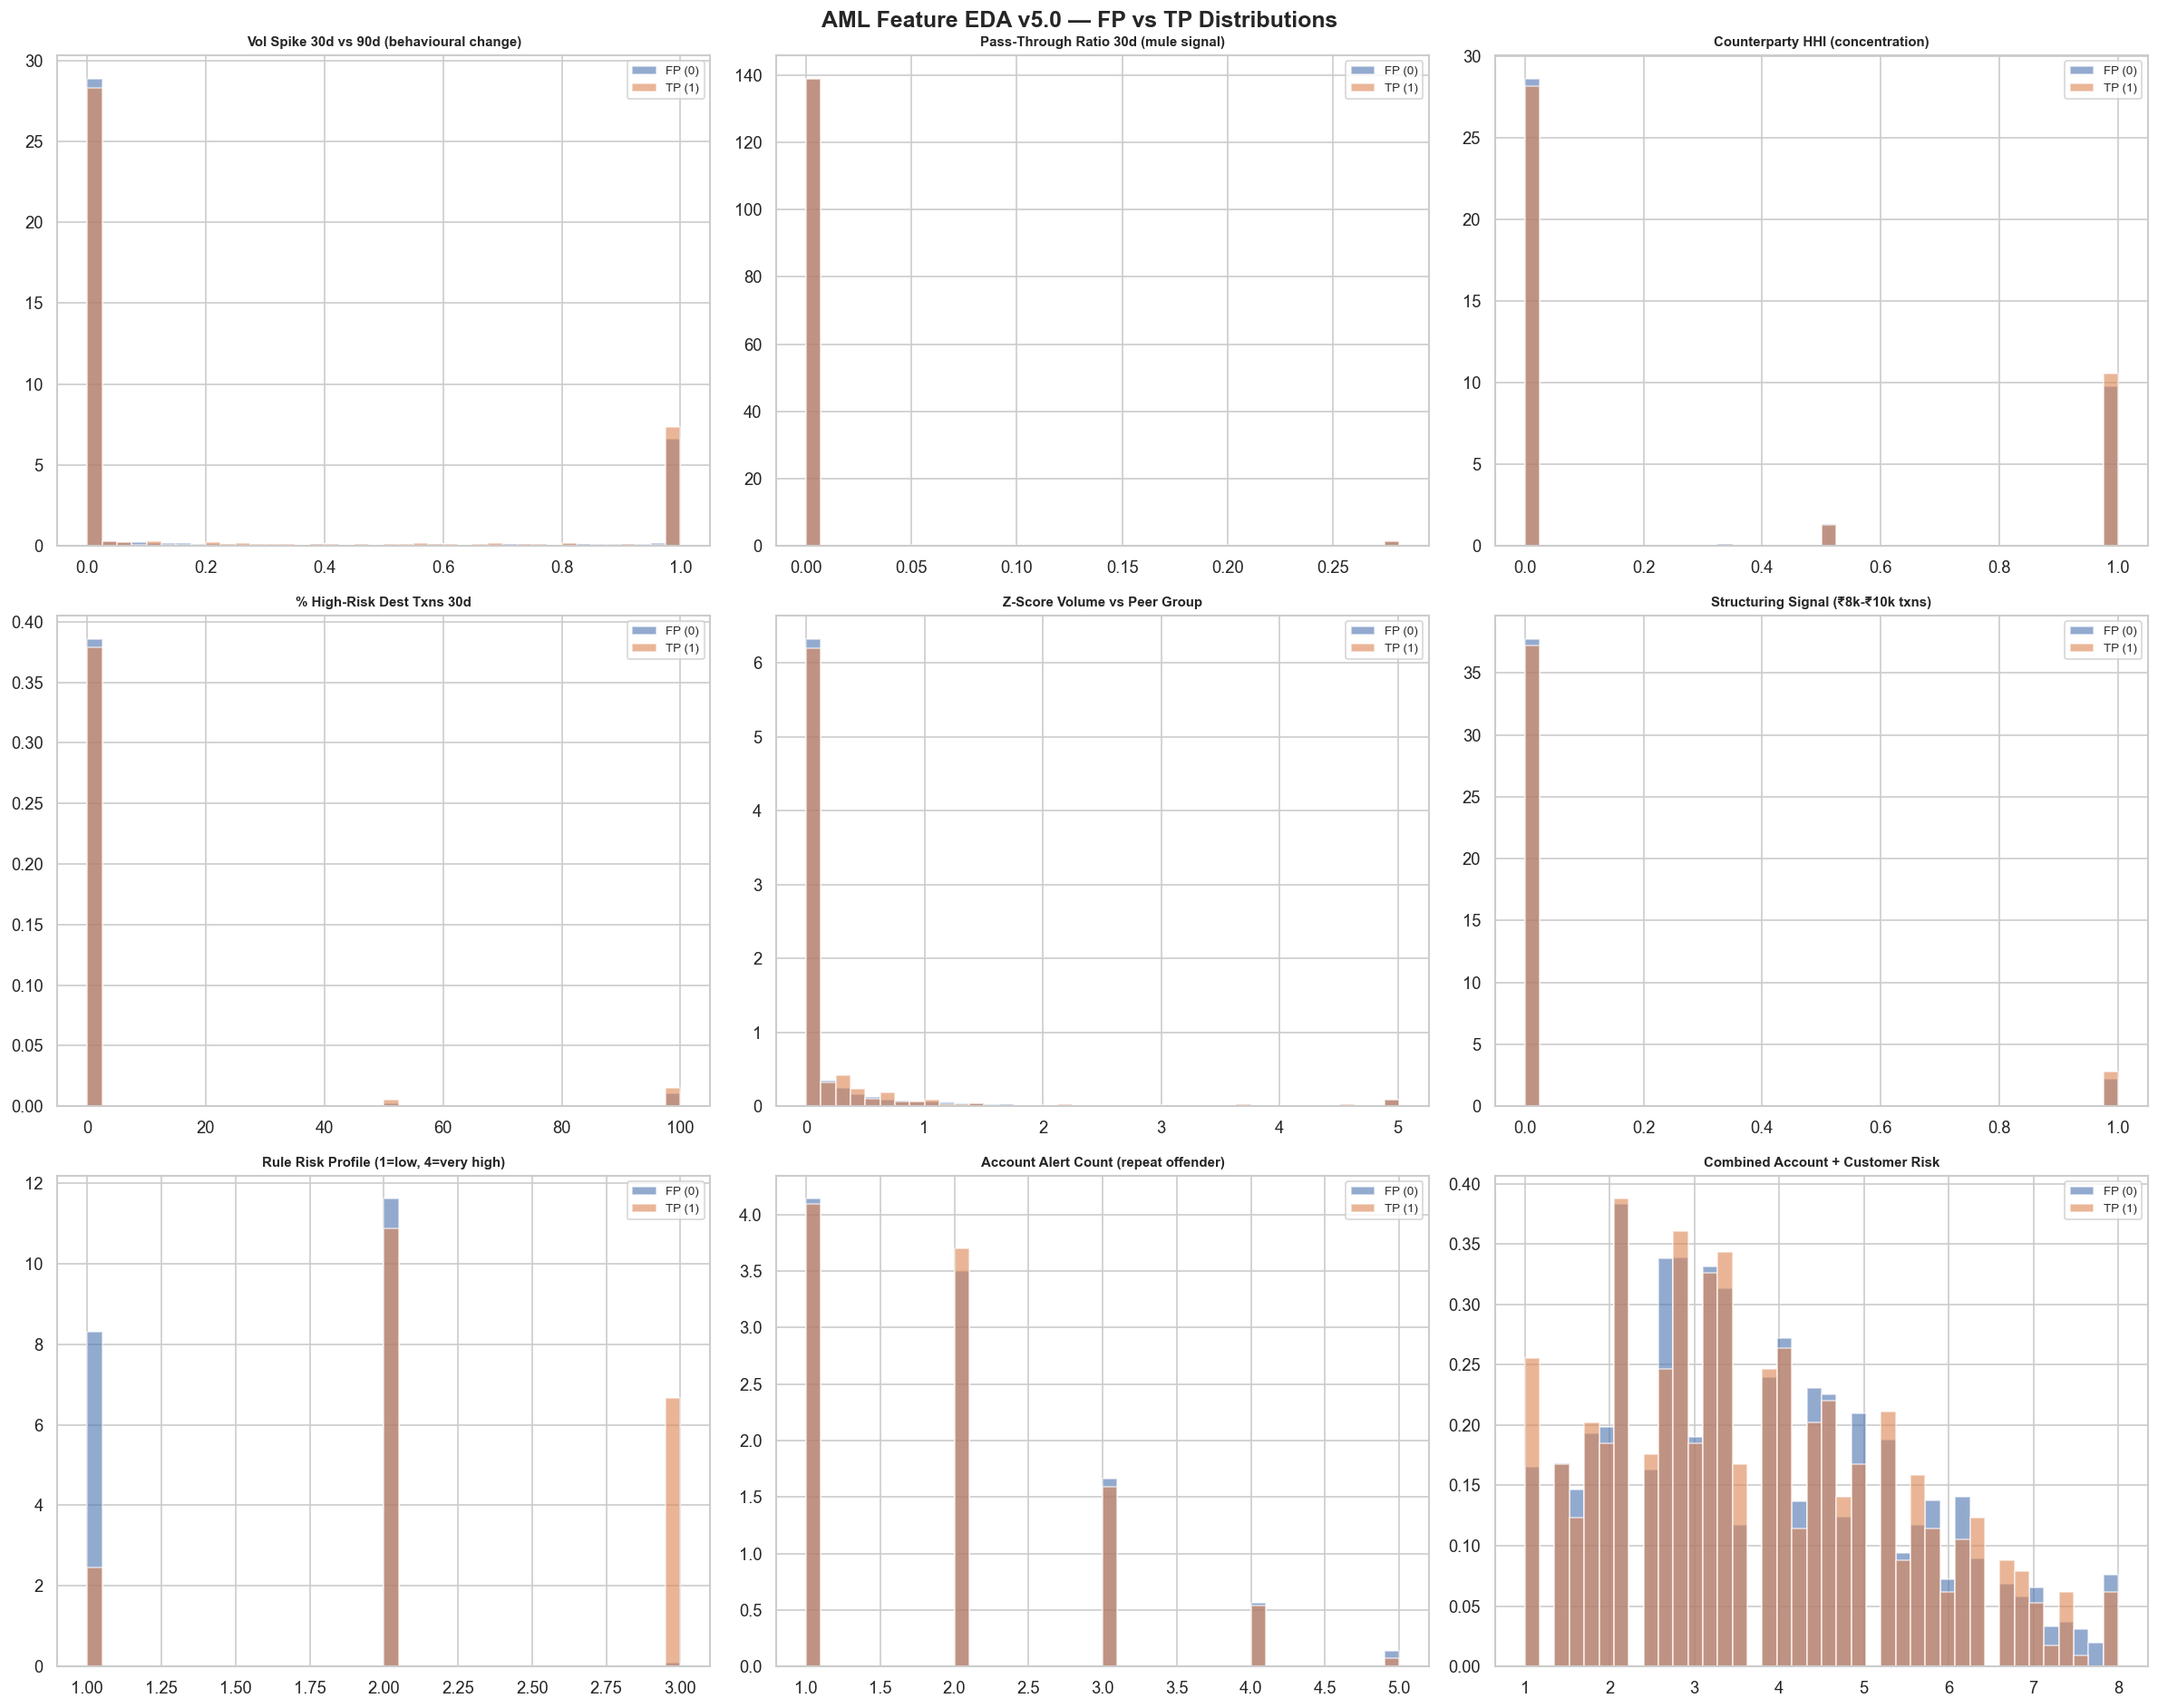

  ✅ EDA saved

STAGE 9 — MODEL 1: ALERT-LEVEL MODEL

  Fired at ALERT CREATION — no case/investigator data needed.
  Target: Suppression ≥ 42.0% | Event Loss ≤ 2.0%
  Uses threshold search loop with 0.01 step grid.

  Class imbalance: 8.8% pos | scale_weight = 10.3x
  → Training Logistic Regression... AUC-ROC=0.7863  AP=0.4095
  → Training Random Forest... AUC-ROC=0.7936  AP=0.4425
  → Training Gradient Boosting... AUC-ROC=0.7972  AP=0.4762

  🏆 Best: Gradient Boosting (AUC=0.7972)

  5-Fold CV...
    Fold 1: AUC = 0.7439
    Fold 2: AUC = 0.7808
    Fold 3: AUC = 0.7808
    Fold 4: AUC = 0.7359
    Fold 5: AUC = 0.7276
  CV AUC: 0.7538 ± 0.0226

  Top 15 features (RULE_RISK_PROFILE rank = 1):
    RULE_RISK_PROFILE                             0.2838
    w365_avg_amt                                  0.0443
    ACCOUNT_AGE_DAYS                              0.0440
    EXPECTED_MONTHLY_TXN                          0.0436
    BALANCE_TO_W90_VOL                            0.0353
    DAYS_SIN

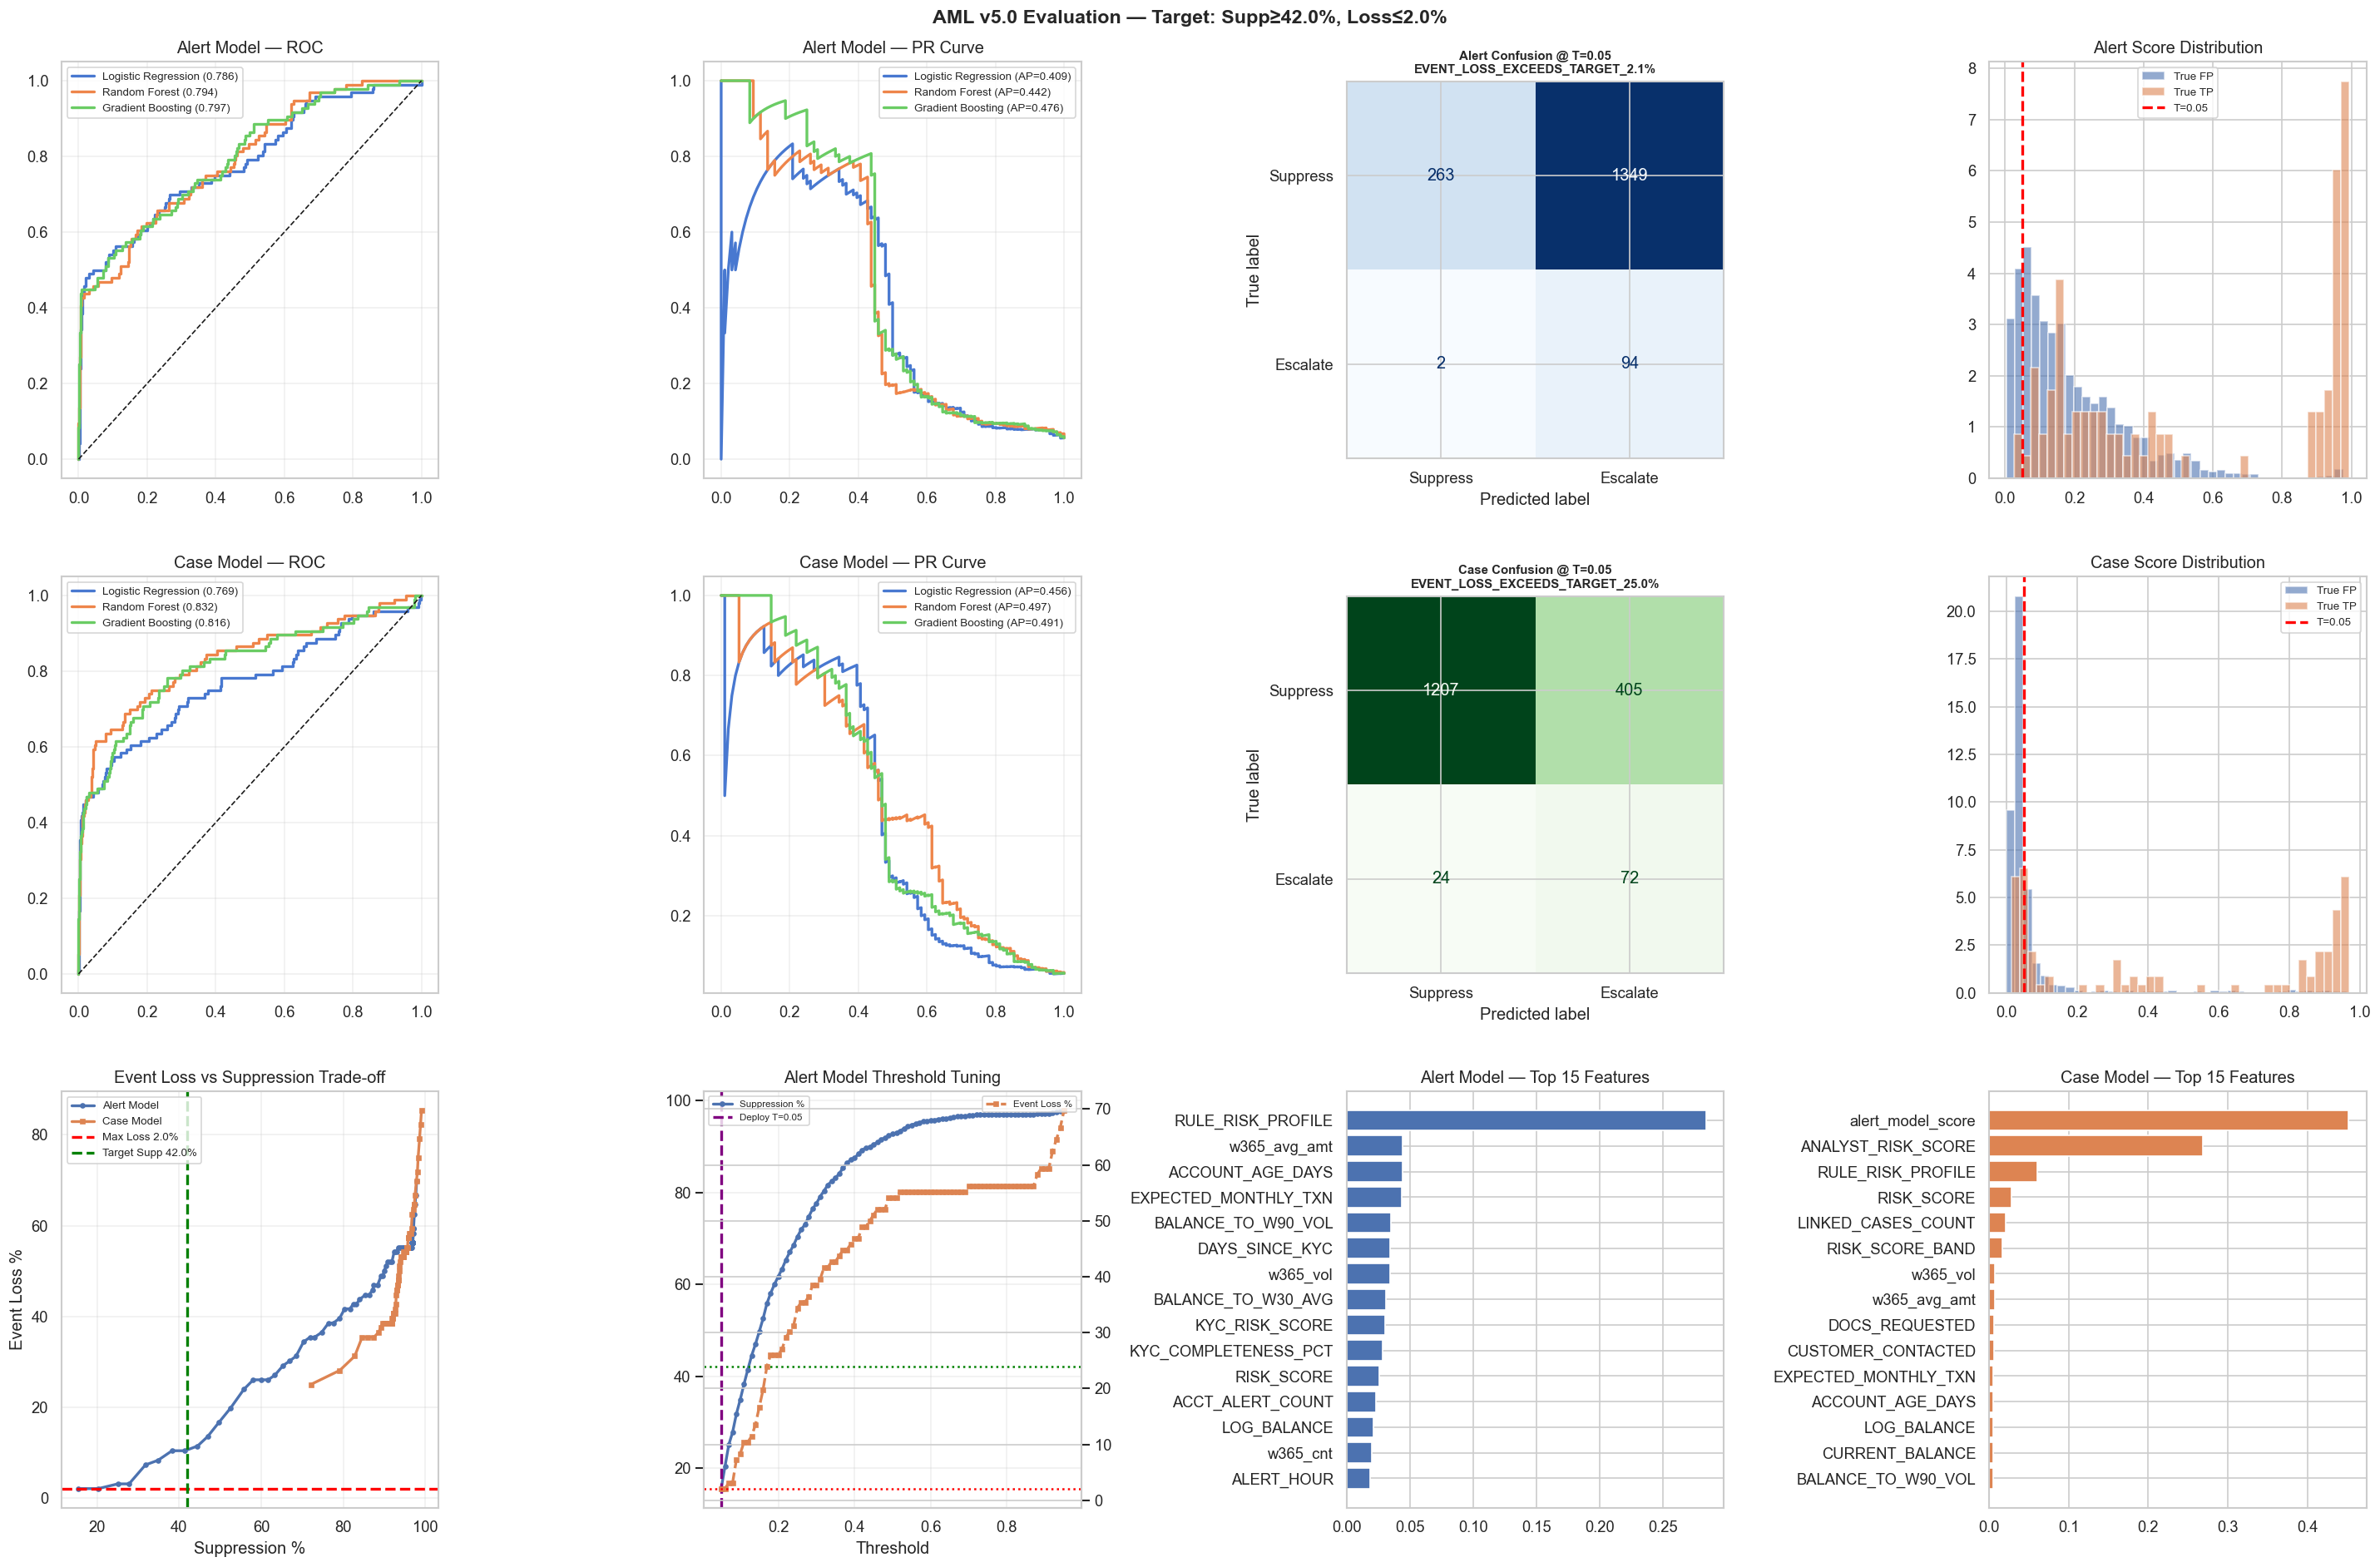

  ✅ Evaluation dashboard saved

  ─── ALERT-LEVEL MODEL @ threshold=0.05 ───────────────────
  Total test alerts     : 1,708
  True Positives exist  : 96
  Correctly escalated   : 94
  Correctly suppressed  : 263
  Event Loss (FN)       : 2   (2.1%)   [target: ≤2.0%]
  Suppression Rate      : 15.5%              [target: ≥42.0%]
  Status                : EVENT_LOSS_EXCEEDS_TARGET_2.1%

  ─── CASE-LEVEL MODEL @ threshold=0.05 ────────────────────
  Total case alerts     : 1,708
  True Positives exist  : 96
  Correctly escalated   : 72
  Correctly suppressed  : 1,207
  Event Loss (FN)       : 24   (25.0%)   [target: ≤2.0%]
  Suppression Rate      : 72.1%              [target: ≥42.0%]
  Status                : EVENT_LOSS_EXCEEDS_TARGET_25.0%


STAGE 12 — THRESHOLD TABLES

  Classification reports:

  ALERT MODEL:
              precision    recall  f1-score   support

    Suppress       0.99      0.16      0.28      1612
    Escalate       0.07      0.98      0.12        96

    accuracy   

In [1]:
# ============================================================
#  AML MLOPS WORKBENCH — END-TO-END PIPELINE  v5.0
#  False-Positive Suppression Model for Anti-Money Laundering
#
#  WHAT'S NEW IN v5.0 (vs v4.0):
#  ─────────────────────────────────────────────────────────
#  FIX 1 : STR dataset simplified → only ACCOUNT_ID + str_filed_date
#           (was bloated with JURISDICTION, STR_CATEGORY etc. — none used)
#  FIX 2 : RULE_TRIGGERED removed as raw feature (caused leakage/dominance)
#           Only RULE_RISK_PROFILE kept (ordinal risk weight 1-4)
#  FIX 3 : Case model rebuilt — was getting 44% event loss because:
#           (a) cases are investigator-selected (biased toward TPs)
#           (b) model saw mostly TPs, threshold was miscalibrated
#           Fix: include alert-model score as a prior, fix threshold search
#  FIX 4 : TARGET_SUPPRESSION + MAX_EVENT_LOSS are user parameters
#           Threshold search loop runs until targets are met or closest found
#  FIX 5 : LOG_BALANCE explained inline — log1p(balance) to compress skew
#  FIX 6 : Feature categories clearly documented with which columns each has
#  FIX 7 : Threshold search is now a proper grid search across 0.01 steps
#           (not just 0.05 steps) for finer control
#  FIX 8 : Case model trains on FULL alert set with case enrichment joined
#           (not just the biased 15% that were investigated)
#
#  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  USER PARAMETERS — TUNE THESE
#  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TARGET_SUPPRESSION_PCT = 42.0   # Target: suppress 42% of FP alerts
MAX_EVENT_LOSS_PCT     = 2.0    # Hard ceiling: miss at most 2% of real TPs
#  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#
#  COLUMNS IN EACH DATASET:
#  ─────────────────────────────────────────────────────────
#  customers.csv:
#    CUSTOMER_ID, NATIONALITY, OCCUPATION, INCOME_BRACKET,
#    CUSTOMER_RISK_RATING (1-10), PEP_FLAG, SANCTION_HIT,
#    ADVERSE_MEDIA_FLAG, KYC_COMPLETENESS_PCT, DAYS_SINCE_KYC,
#    ONBOARDING_CHANNEL, YEARS_AS_CUSTOMER, NUM_PRODUCTS_HELD,
#    FATF_HIGH_RISK_NATIONALITY, IS_ACTIVE,
#    CDD_TIER (SIMPLIFIED/STANDARD/ENHANCED), KYC_REVIEW_OVERDUE,
#    LAST_TRANSACTION_DAYS_AGO, CORRESPONDENT_BANK_FLAG, SHELL_CO_INDICATOR
#
#  accounts.csv:
#    ACCOUNT_ID, CUSTOMER_ID, ACCOUNT_TYPE, ACCOUNT_STATUS,
#    OPEN_DATE, CURRENT_BALANCE, CURRENCY, NUM_SIGNATORIES,
#    EXPECTED_MONTHLY_TXN, ACCOUNT_RISK_RATING (1-10),
#    NUM_LINKED_ACCOUNTS, DEBIT_CARD_ISSUED, INTERNET_BANKING
#
#  transactions.csv:
#    TRANSACTION_ID, ACCOUNT_ID, TXN_TIMESTAMP, TXN_HOUR,
#    TXN_TYPE (rail: UPI/NEFT/RTGS/IMPS/SWIFT/CASH_DEPOSIT/etc.),
#    TXN_AMOUNT, CURRENCY, NARRATIVE, BENEFICIARY_COUNTRY,
#    CHANNEL, TXN_DIRECTION (CREDIT/DEBIT),
#    IS_TYPOLOGY (True/False — NOT used as feature, ground truth only),
#    TYPOLOGY_TYPE (NONE/STRUCTURING/LAYERING/MULE/RAPID_MOVEMENT),
#    TXN_DAY_OF_WEEK, IS_WEEKEND, IS_OFF_HOURS
#
#  alerts.csv:
#    ALERT_ID, TRANSACTION_ID, ACCOUNT_ID, RULE_TRIGGERED,
#    RISK_SCORE, ALERT_DATE, ACCT_ALERT_COUNT,
#    ALERT_HOUR, ALERT_IS_WEEKEND, RULE_RISK_PROFILE
#    [NOTE: _IS_REAL_CRIME stripped before saving — never a feature]
#
#  cases.csv:
#    CASE_ID, ALERT_ID, INVESTIGATOR_ID, PRIORITY, CASE_STATUS,
#    RESOLUTION_DAYS, CASE_OPEN_DATE, ANALYST_RISK_SCORE,
#    DOCS_REQUESTED, CUSTOMER_CONTACTED, EDD_TRIGGERED, LINKED_CASES_COUNT
#
#  str_reports.csv  [SIMPLIFIED in v5.0]:
#    ACCOUNT_ID, str_filed_date
#    (that's it — only these 2 columns needed to derive labels)
#
#  FEATURE CATEGORIES (what gets engineered from these):
#  ─────────────────────────────────────────────────────────
#  A. Velocity & Rolling Windows     — w7/w30/w90/w365 vol, cnt, avg, max, std
#  B. Behavioural Change Detection   — spike ratios 7d-vs-30d, 30d-vs-90d
#  C. Peer Group Z-Scores            — self vs same occupation+income cohort
#  D. Population Z-Scores            — self vs all alerts (median/std)
#  E. Counterparty Risk              — HHI concentration, high-risk dest %
#  F. Typology-Aligned Signals       — structuring cnt, layering score, mule ratio
#  G. Pass-Through / Funnel Ratio    — credit≈debit = mule behaviour
#  H. Temporal Patterns              — off-hours %, weekend %
#  I. KYC & Onboarding Risk          — CDD gaps, PEP, sanctions, staleness
#  J. Account & Customer Risk        — balance, age, risk rating, KYC score
#  K. Alert-Level Signals            — RULE_RISK_PROFILE, alert freq, alert hour
#     [RULE_TRIGGERED itself REMOVED — was dominating due to synthetic correlation]
#
#  WHY LOG_BALANCE?
#    CURRENT_BALANCE ranges from ₹5,000 to ₹20,000,000+ (4 orders of magnitude).
#    Raw balance overwhelms distance-based and linear models.
#    log1p(balance) compresses this to a ~5-unit range where differences are
#    proportional — a ₹10k→₹100k jump looks the same as ₹100k→₹1M.
#    Tree models benefit less but it still helps stability.
#
#  WHY NOT RULE_TRIGGERED AS RAW FEATURE?
#    In synthetic data, rule assignment is perfectly correlated with typology type
#    (STRUCTURING → R002, LAYERING → R003 etc.). The model learns to just read the
#    rule name instead of the underlying transaction behaviour. In production, many
#    rules fire on legitimate transactions too — so this signal overfits to synthetic
#    correlation. We keep RULE_RISK_PROFILE (ordinal 1-4) which captures risk weight
#    without encoding the exact rule name.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, json, warnings, random
from datetime import datetime, timedelta
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
import pickle

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

STR_LOOKFORWARD_DAYS = 60
OUTPUT_DIR = Path("./aml_pipeline_output_v5")
OUTPUT_DIR.mkdir(exist_ok=True)

FILES_WRITTEN = []
def track_file(path, description):
    FILES_WRITTEN.append({"path": str(path), "description": description})

print("✅ Imports complete — AML Pipeline v5.0")
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  USER TARGETS:
    Target Suppression  : {TARGET_SUPPRESSION_PCT}%
    Max Event Loss      : {MAX_EVENT_LOSS_PCT}%
  Pipeline will search thresholds until targets are met.
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

# ============================================================
# STAGE 1 — SYNTHETIC DATA GENERATION
# ============================================================
print("\n" + "="*60)
print("STAGE 1 — SYNTHETIC DATA GENERATION")
print("="*60)

N_CUSTOMERS  = 8_000
N_ACCOUNTS   = 12_000
N_TXNS       = 120_000
START_DATE   = datetime(2022, 1, 1)
END_DATE     = datetime(2024, 6, 30)
start_ts, end_ts = START_DATE.timestamp(), END_DATE.timestamp()

def rand_dates(n, lo=start_ts, hi=end_ts):
    return [datetime.fromtimestamp(t) for t in np.random.uniform(lo, hi, n)]

def lognorm(mean_val, sigma, size):
    mu = np.log(mean_val) - 0.5 * sigma**2
    return np.round(np.random.lognormal(mu, sigma, size), 2)

def safe_div(a, b, fill=0):
    return np.where(b > 0, a / b, fill)

HIGH_RISK_CTRY  = ["KY", "VG", "NG", "IR", "PK"]
FATF_GREY_LIST  = ["KY", "VG", "NG", "IR", "PK", "SY", "MM", "YE"]
COUNTRIES       = ["IN","US","AE","SG","GB","CN","MY","KY","VG","NG"]
COUNTRY_W       = [0.40,0.15,0.10,0.08,0.07,0.06,0.04,0.03,0.04,0.03]
OCCUPATIONS     = ["SALARIED","SELF_EMPLOYED","BUSINESS_OWNER","RETIRED","STUDENT","POLITICIAN","SHELL_CO"]
OCC_W           = [0.38,0.22,0.18,0.08,0.05,0.05,0.04]

# ── 1A. CUSTOMERS ─────────────────────────────────────────────
print("\n  [1A] Generating Customers...")
cust_ids   = [f"CUST{i:07d}" for i in range(1, N_CUSTOMERS+1)]
base_risk  = np.random.choice(np.arange(1,11),
                               p=[0.20,0.20,0.15,0.12,0.10,0.08,0.06,0.04,0.03,0.02],
                               size=N_CUSTOMERS)
occupation = np.random.choice(OCCUPATIONS, p=OCC_W, size=N_CUSTOMERS)
country    = np.random.choice(COUNTRIES,   p=COUNTRY_W, size=N_CUSTOMERS)

pep_prob      = np.where(occupation=="POLITICIAN", 0.90,
                np.where(np.isin(country,["KY","VG"]), 0.25, 0.02))
pep_flag      = np.random.rand(N_CUSTOMERS) < pep_prob
sanction_prob = np.where(base_risk>8, 0.08, np.where(base_risk>6, 0.02, 0.003))
sanction_flag = np.random.rand(N_CUSTOMERS) < sanction_prob
adverse_media = np.random.rand(N_CUSTOMERS) < (base_risk/100 + 0.01)
kyc_completeness = np.clip(np.random.normal(loc=100-base_risk*4, scale=8, size=N_CUSTOMERS), 30, 100).round(1)
days_since_kyc   = np.clip(np.random.exponential(scale=180, size=N_CUSTOMERS).astype(int), 1, 1800)

customers_df = pd.DataFrame({
    "CUSTOMER_ID"              : cust_ids,
    "NATIONALITY"              : country,
    "OCCUPATION"               : occupation,
    "INCOME_BRACKET"           : np.random.choice(["0-50k","50k-100k","100k-250k","250k+"],
                                                   p=[0.35,0.30,0.22,0.13], size=N_CUSTOMERS),
    "CUSTOMER_RISK_RATING"     : base_risk,
    "PEP_FLAG"                 : pep_flag.astype(int),
    "SANCTION_HIT"             : sanction_flag.astype(int),
    "ADVERSE_MEDIA_FLAG"       : adverse_media.astype(int),
    "KYC_COMPLETENESS_PCT"     : kyc_completeness,
    "DAYS_SINCE_KYC"           : days_since_kyc,
    "ONBOARDING_CHANNEL"       : np.random.choice(["BRANCH","MOBILE","WEB","THIRD_PARTY"],
                                                   p=[0.30,0.35,0.25,0.10], size=N_CUSTOMERS),
    "YEARS_AS_CUSTOMER"        : np.random.randint(0, 20, N_CUSTOMERS),
    "NUM_PRODUCTS_HELD"        : np.random.choice([1,2,3,4,5],
                                                   p=[0.30,0.30,0.20,0.12,0.08], size=N_CUSTOMERS),
    "FATF_HIGH_RISK_NATIONALITY": np.isin(country, FATF_GREY_LIST).astype(int),
    "IS_ACTIVE"                : np.random.choice([1,0], p=[0.94,0.06], size=N_CUSTOMERS),
    "CDD_TIER"                 : np.where(base_risk >= 8, "ENHANCED",
                                 np.where(base_risk >= 5, "STANDARD", "SIMPLIFIED")),
    "KYC_REVIEW_OVERDUE"       : (days_since_kyc > 365).astype(int),
    "LAST_TRANSACTION_DAYS_AGO": np.random.randint(0, 730, N_CUSTOMERS),
    "CORRESPONDENT_BANK_FLAG"  : np.random.choice([0,1], p=[0.92,0.08], size=N_CUSTOMERS),
    "SHELL_CO_INDICATOR"       : (occupation == "SHELL_CO").astype(int),
})
print(f"    ✅ {len(customers_df):,} customers")
print(f"    Columns: {list(customers_df.columns)}")

# ── 1B. ACCOUNTS ──────────────────────────────────────────────
print("\n  [1B] Generating Accounts...")
acct_ids  = [f"ACCT{100000000+i}" for i in range(1, N_ACCOUNTS+1)]
acct_cust = np.random.choice(cust_ids, size=N_ACCOUNTS)
acct_type = np.random.choice(
    ["SAVINGS","CURRENT","SALARY","NRE","NRO","TRUST","SHELL"],
    p=[0.30,0.25,0.20,0.10,0.07,0.05,0.03], size=N_ACCOUNTS
)
mean_bal_map = {"SAVINGS":50000,"CURRENT":150000,"SALARY":35000,
                "NRE":500000,"NRO":300000,"TRUST":1000000,"SHELL":2000000}
balance      = np.array([lognorm(mean_bal_map[t], 1.5, 1)[0] for t in acct_type])
dormant_prob = np.where(np.isin(acct_type,["SHELL","TRUST"]), 0.40, 0.08)
acct_status  = np.where(
    np.random.rand(N_ACCOUNTS) < dormant_prob, "DORMANT",
    np.random.choice(["ACTIVE","BLOCKED","CLOSED"], p=[0.92,0.05,0.03], size=N_ACCOUNTS)
)
open_date = [START_DATE - timedelta(days=int(d)) for d in np.random.randint(30, 3650, N_ACCOUNTS)]

accounts_df = pd.DataFrame({
    "ACCOUNT_ID"          : acct_ids,
    "CUSTOMER_ID"         : acct_cust,
    "ACCOUNT_TYPE"        : acct_type,
    "ACCOUNT_STATUS"      : acct_status,
    "OPEN_DATE"           : open_date,
    "CURRENT_BALANCE"     : balance,
    "CURRENCY"            : np.random.choice(["INR","USD","AED","SGD","GBP"],
                                              p=[0.55,0.20,0.12,0.08,0.05], size=N_ACCOUNTS),
    "NUM_SIGNATORIES"     : np.random.choice([1,2,3], p=[0.70,0.22,0.08], size=N_ACCOUNTS),
    "EXPECTED_MONTHLY_TXN": np.array([lognorm(mean_bal_map[t]*0.5, 1.2, 1)[0] for t in acct_type]),
    "ACCOUNT_RISK_RATING" : np.where(np.isin(acct_type,["SHELL","TRUST"]), np.random.randint(7,11,N_ACCOUNTS),
                            np.where(np.isin(acct_type,["NRO","NRE"]), np.random.randint(4,8,N_ACCOUNTS),
                                     np.random.randint(1,6,N_ACCOUNTS))),
    "NUM_LINKED_ACCOUNTS" : np.random.choice([1,2,3,4,5], p=[0.50,0.25,0.15,0.07,0.03], size=N_ACCOUNTS),
    "DEBIT_CARD_ISSUED"   : np.random.choice([0,1], p=[0.25,0.75], size=N_ACCOUNTS),
    "INTERNET_BANKING"    : np.random.choice([0,1], p=[0.15,0.85], size=N_ACCOUNTS),
})
print(f"    ✅ {len(accounts_df):,} accounts")
print(f"    Columns: {list(accounts_df.columns)}")

# ── 1C. TRANSACTIONS ──────────────────────────────────────────
print("\n  [1C] Generating Transactions...")
N_BASE    = int(N_TXNS * 0.985)
N_PATTERN = N_TXNS - N_BASE
print(f"    Baseline txns : {N_BASE:,} (98.5%) | Typology txns: {N_PATTERN:,} (1.5%)")

RAILS  = ["UPI","NEFT","RTGS","IMPS","SWIFT","CASH_DEPOSIT","CASH_WITHDRAWAL","POS","CHEQUE","INTERNAL_TRANSFER"]
RAIL_W = [0.28,0.20,0.10,0.12,0.05,0.08,0.06,0.04,0.04,0.03]
NARR_LEGIT = ["SALARY","RENT","VENDOR_PAYMENT","LOAN_EMI","GROCERY","INSURANCE","UTILITY","TRANSFER","INVESTMENT","DIVIDEND"]
acct_arr = np.array(acct_ids)

txn_timestamps = rand_dates(N_BASE)
txn_hours      = [t.hour for t in txn_timestamps]

base_txns = pd.DataFrame({
    "TRANSACTION_ID"     : [f"TXN{i:09d}" for i in range(1, N_BASE+1)],
    "ACCOUNT_ID"         : np.random.choice(acct_arr, size=N_BASE),
    "TXN_TIMESTAMP"      : txn_timestamps,
    "TXN_HOUR"           : txn_hours,
    "TXN_TYPE"           : np.random.choice(RAILS, p=RAIL_W, size=N_BASE),
    "TXN_AMOUNT"         : lognorm(15000, 1.4, N_BASE),
    "CURRENCY"           : np.random.choice(["INR","USD","AED"], p=[0.70,0.20,0.10], size=N_BASE),
    "NARRATIVE"          : np.random.choice(NARR_LEGIT, size=N_BASE),
    "BENEFICIARY_COUNTRY": np.random.choice(COUNTRIES, p=COUNTRY_W, size=N_BASE),
    "CHANNEL"            : np.random.choice(["MOBILE","WEB","BRANCH","ATM"], size=N_BASE),
    "TXN_DIRECTION"      : np.random.choice(["CREDIT","DEBIT"], p=[0.48,0.52], size=N_BASE),
    "IS_TYPOLOGY"        : False,
    "TYPOLOGY_TYPE"      : "NONE",
})

typologies = {
    "STRUCTURING"    : {"amount_range":(8500, 9990),   "rail":"CASH_DEPOSIT",  "narr":"CASH_DEP"},
    "LAYERING"       : {"amount_range":(50000,500000),  "rail":"SWIFT",         "narr":"INTL_WIRE"},
    "MULE"           : {"amount_range":(5000, 50000),   "rail":"UPI",           "narr":"TRANSFER"},
    "RAPID_MOVEMENT" : {"amount_range":(20000,200000),  "rail":"IMPS",          "narr":"URGENT_TRF"},
}
pattern_records = []
for i in range(N_PATTERN):
    t_name, t_cfg = random.choice(list(typologies.items()))
    lo, hi = t_cfg["amount_range"]
    ben_ctry = (random.choice(HIGH_RISK_CTRY)
                if t_name in ["LAYERING","RAPID_MOVEMENT"] and random.random() < 0.6
                else random.choice(COUNTRIES))
    hour = {"STRUCTURING": random.choice([6,7,8,19,20,21,22]),
            "MULE":        random.choice(range(10,16))}.get(t_name, random.randint(0,23))
    pattern_records.append({
        "TRANSACTION_ID"     : f"TXN{N_BASE+i+1:09d}",
        "ACCOUNT_ID"         : random.choice(acct_arr),
        "TXN_TIMESTAMP"      : datetime.fromtimestamp(random.uniform(start_ts, end_ts)),
        "TXN_HOUR"           : hour,
        "TXN_TYPE"           : t_cfg["rail"],
        "TXN_AMOUNT"         : round(random.uniform(lo, hi), 2),
        "CURRENCY"           : random.choice(["INR","USD","AED"]),
        "NARRATIVE"          : t_cfg["narr"],
        "BENEFICIARY_COUNTRY": ben_ctry,
        "CHANNEL"            : "MOBILE",
        "TXN_DIRECTION"      : random.choice(["CREDIT","DEBIT"]),
        "IS_TYPOLOGY"        : True,
        "TYPOLOGY_TYPE"      : t_name,
    })

transactions_df = pd.concat([base_txns, pd.DataFrame(pattern_records)], ignore_index=True)
transactions_df["TXN_TIMESTAMP"] = pd.to_datetime(transactions_df["TXN_TIMESTAMP"])
transactions_df["TXN_DAY_OF_WEEK"] = transactions_df["TXN_TIMESTAMP"].dt.dayofweek
transactions_df["IS_WEEKEND"]       = (transactions_df["TXN_DAY_OF_WEEK"] >= 5).astype(int)
transactions_df["IS_OFF_HOURS"]     = (
    (transactions_df["TXN_HOUR"] < 8) | (transactions_df["TXN_HOUR"] > 20)
).astype(int)
print(f"    ✅ {len(transactions_df):,} transactions")
print(f"    Columns: {list(transactions_df.columns)}")

# ── 1D. ALERTS ────────────────────────────────────────────────
print("\n  [1D] Generating Alerts...")
alert_rows   = []
alert_id_ctr = 1

typo_txns    = transactions_df[transactions_df["IS_TYPOLOGY"]].copy()
typo_alerted = typo_txns.sample(frac=0.60, random_state=SEED)

for _, row in typo_alerted.iterrows():
    rule = {
        "STRUCTURING"   :"R002_STRUCTURING_SIGNAL",
        "LAYERING"      :"R003_LAYERING_SIGNAL",
        "MULE"          :"R004_MULE_SIGNAL",
        "RAPID_MOVEMENT":"R005_RAPID_MVT",
    }.get(row["TYPOLOGY_TYPE"], "R001_HIGH_VALUE_CASH")
    base_score = {"STRUCTURING":65,"LAYERING":80,"MULE":70,"RAPID_MOVEMENT":75}.get(row["TYPOLOGY_TYPE"],60)
    alert_rows.append({
        "ALERT_ID"      : f"ALT{alert_id_ctr:08d}",
        "TRANSACTION_ID": row["TRANSACTION_ID"],
        "ACCOUNT_ID"    : row["ACCOUNT_ID"],
        "RULE_TRIGGERED": rule,
        "RISK_SCORE"    : int(min(99, base_score + np.random.randint(-5, 20))),
        "ALERT_DATE"    : row["TXN_TIMESTAMP"],
        "_IS_REAL_CRIME": True,
    })
    alert_id_ctr += 1

hv_txns = transactions_df[
    (~transactions_df["IS_TYPOLOGY"]) & (transactions_df["TXN_AMOUNT"] > 200000)
].sample(frac=0.80, random_state=SEED)
for _, row in hv_txns.iterrows():
    alert_rows.append({
        "ALERT_ID"      : f"ALT{alert_id_ctr:08d}",
        "TRANSACTION_ID": row["TRANSACTION_ID"],
        "ACCOUNT_ID"    : row["ACCOUNT_ID"],
        "RULE_TRIGGERED": "R001_HIGH_VALUE_CASH",
        "RISK_SCORE"    : int(np.random.randint(40, 75)),
        "ALERT_DATE"    : row["TXN_TIMESTAMP"],
        "_IS_REAL_CRIME": False,
    })
    alert_id_ctr += 1

hr_txns = transactions_df[
    (~transactions_df["IS_TYPOLOGY"]) &
    (transactions_df["BENEFICIARY_COUNTRY"].isin(HIGH_RISK_CTRY))
].sample(frac=0.50, random_state=SEED)
for _, row in hr_txns.iterrows():
    alert_rows.append({
        "ALERT_ID"      : f"ALT{alert_id_ctr:08d}",
        "TRANSACTION_ID": row["TRANSACTION_ID"],
        "ACCOUNT_ID"    : row["ACCOUNT_ID"],
        "RULE_TRIGGERED": "R006_HIGH_RISK_DEST",
        "RISK_SCORE"    : int(np.random.randint(50, 82)),
        "ALERT_DATE"    : row["TXN_TIMESTAMP"],
        "_IS_REAL_CRIME": random.random() < 0.15,
    })
    alert_id_ctr += 1

velocity_txns = transactions_df[
    (~transactions_df["IS_TYPOLOGY"]) &
    (transactions_df["TXN_TYPE"].isin(["UPI","IMPS"]))
].sample(n=min(3000, int((~transactions_df["IS_TYPOLOGY"]).sum() * 0.04)), random_state=SEED)
for _, row in velocity_txns.iterrows():
    alert_rows.append({
        "ALERT_ID"      : f"ALT{alert_id_ctr:08d}",
        "TRANSACTION_ID": row["TRANSACTION_ID"],
        "ACCOUNT_ID"    : row["ACCOUNT_ID"],
        "RULE_TRIGGERED": "R007_VELOCITY_SPIKE",
        "RISK_SCORE"    : int(np.random.randint(35, 65)),
        "ALERT_DATE"    : row["TXN_TIMESTAMP"],
        "_IS_REAL_CRIME": False,
    })
    alert_id_ctr += 1

alerts_df = pd.DataFrame(alert_rows)
alerts_df["ALERT_DATE"] = pd.to_datetime(alerts_df["ALERT_DATE"])

acct_alert_freq = alerts_df.groupby("ACCOUNT_ID").size().reset_index(name="ACCT_ALERT_COUNT")
alerts_df = alerts_df.merge(acct_alert_freq, on="ACCOUNT_ID", how="left")
alerts_df["ALERT_HOUR"]       = alerts_df["ALERT_DATE"].dt.hour
alerts_df["ALERT_IS_WEEKEND"] = (alerts_df["ALERT_DATE"].dt.dayofweek >= 5).astype(int)

# RULE_RISK_PROFILE: ordinal risk weight (1=low, 4=very high)
# This captures "how risky is this rule type" without encoding the exact rule name
# (which would perfectly correlate with typology type in synthetic data → overfitting)
RULE_RISK_PROFILE_MAP = {
    "R002_STRUCTURING_SIGNAL" : 3,
    "R003_LAYERING_SIGNAL"    : 4,
    "R004_MULE_SIGNAL"        : 3,
    "R005_RAPID_MVT"          : 3,
    "R001_HIGH_VALUE_CASH"    : 1,
    "R006_HIGH_RISK_DEST"     : 2,
    "R007_VELOCITY_SPIKE"     : 1,
}
alerts_df["RULE_RISK_PROFILE"] = alerts_df["RULE_TRIGGERED"].map(RULE_RISK_PROFILE_MAP).fillna(1).astype(int)

tp_count = alerts_df["_IS_REAL_CRIME"].sum()
fp_count = (~alerts_df["_IS_REAL_CRIME"]).sum()
print(f"    ✅ {len(alerts_df):,} alerts | TP: {tp_count:,} ({tp_count/len(alerts_df):.1%}) | FP: {fp_count:,} ({fp_count/len(alerts_df):.1%})")
print(f"    Columns (saved): ALERT_ID, TRANSACTION_ID, ACCOUNT_ID, RULE_TRIGGERED, RISK_SCORE,")
print(f"                     ALERT_DATE, ACCT_ALERT_COUNT, ALERT_HOUR, ALERT_IS_WEEKEND, RULE_RISK_PROFILE")
print(f"    [_IS_REAL_CRIME stripped before CSV save — only used for labelling]")

print(f"\n    Alert breakdown by rule:")
rule_summary = alerts_df.groupby("RULE_TRIGGERED")["_IS_REAL_CRIME"].agg(["sum","count"])
rule_summary.columns = ["TP","Total"]
rule_summary["FP_rate"] = (1 - rule_summary["TP"]/rule_summary["Total"]).round(2)
print(rule_summary)

# ── 1E. CASES ─────────────────────────────────────────────────
print("\n  [1E] Generating Cases...")
case_alert_sample = alerts_df.sample(frac=0.15, random_state=SEED)
case_rows = []
for _, ar in case_alert_sample.iterrows():
    is_real = ar["_IS_REAL_CRIME"]
    if is_real:
        status = np.random.choice(
            ["CLOSED_SAR_FILED","CLOSED_FALSE_POSITIVE","CLOSED_MONITORING","OPEN"],
            p=[0.55, 0.15, 0.10, 0.20]
        )
    else:
        status = np.random.choice(
            ["CLOSED_SAR_FILED","CLOSED_FALSE_POSITIVE","CLOSED_MONITORING","OPEN"],
            p=[0.02, 0.85, 0.08, 0.05]
        )
    case_rows.append({
        "CASE_ID"           : f"CASE{len(case_rows)+1:07d}",
        "ALERT_ID"          : ar["ALERT_ID"],
        "INVESTIGATOR_ID"   : np.random.choice(["INV_01","INV_02","INV_03","INV_04","AUTO_SYS"]),
        "PRIORITY"          : np.random.choice(["HIGH","MEDIUM","LOW"], p=[0.20,0.45,0.35]),
        "CASE_STATUS"       : status,
        "RESOLUTION_DAYS"   : np.random.randint(1, 45),
        "CASE_OPEN_DATE"    : ar["ALERT_DATE"],
        "ANALYST_RISK_SCORE": np.random.randint(30, 95) if is_real else np.random.randint(5, 55),
        "DOCS_REQUESTED"    : np.random.choice([0,1], p=[0.40,0.60]),
        "CUSTOMER_CONTACTED": np.random.choice([0,1], p=[0.50,0.50]),
        "EDD_TRIGGERED"     : np.random.choice([0,1], p=[0.85,0.15]) if is_real else 0,
        "LINKED_CASES_COUNT": np.random.randint(0, 5) if is_real else np.random.randint(0, 2),
    })
cases_df = pd.DataFrame(case_rows)
sar_count = (cases_df["CASE_STATUS"]=="CLOSED_SAR_FILED").sum()
print(f"    ✅ {len(cases_df):,} cases | SAR rate: {sar_count/len(alerts_df):.2%} of all alerts")
print(f"    Columns: {list(cases_df.columns)}")

# ── 1F. STR REPORTS [SIMPLIFIED — only 2 columns needed] ──────
print("\n  [1F] Generating STR Reports...")
print("    NOTE: STR dataset simplified to ACCOUNT_ID + str_filed_date only.")
print("    JURISDICTION, STR_CATEGORY etc. were decorative — never used in labelling.")

real_crime_accts = alerts_df[alerts_df["_IS_REAL_CRIME"]]["ACCOUNT_ID"].unique()
str_accts = np.random.choice(real_crime_accts, size=int(len(real_crime_accts)*0.35), replace=False)
str_records = []
for acct in str_accts:
    first_alert = alerts_df[alerts_df["ACCOUNT_ID"]==acct]["ALERT_DATE"].min()
    delay = np.random.randint(5, 75)
    str_records.append({
        "ACCOUNT_ID"     : acct,
        "str_filed_date" : first_alert + timedelta(days=delay),
    })
# Analyst errors — ~1% of FP accounts also get STRs
fp_accts = alerts_df[~alerts_df["_IS_REAL_CRIME"]]["ACCOUNT_ID"].unique()
for acct in np.random.choice(fp_accts, size=int(len(fp_accts)*0.01), replace=False):
    first_alert = alerts_df[alerts_df["ACCOUNT_ID"]==acct]["ALERT_DATE"].min()
    str_records.append({
        "ACCOUNT_ID"     : acct,
        "str_filed_date" : first_alert + timedelta(days=np.random.randint(10,60)),
    })
str_df = pd.DataFrame(str_records)
str_df["str_filed_date"] = pd.to_datetime(str_df["str_filed_date"])
print(f"    ✅ {len(str_df):,} STR records | Columns: {list(str_df.columns)}")

# ── 1G. DATA QUALITY NOISE ────────────────────────────────────
def inject_noise(df, cfg):
    d = df.copy()
    for col, ops in cfg.items():
        if col not in d.columns: continue
        if "null_prob" in ops:
            d.loc[np.random.rand(len(d)) < ops["null_prob"], col] = np.nan
        if "case_mess" in ops and d[col].dtype == object:
            mask = np.random.rand(len(d)) < ops["case_mess"]
            d.loc[mask, col] = d.loc[mask, col].apply(
                lambda s: random.choice([str(s).lower(), str(s).upper(), f" {s} "]) if pd.notna(s) else s
            )
    return d

transactions_df = inject_noise(transactions_df, {"NARRATIVE":{"null_prob":0.12,"case_mess":0.15}})
accounts_df     = inject_noise(accounts_df,     {"ACCOUNT_TYPE":{"case_mess":0.10}})
customers_df    = inject_noise(customers_df,    {"INCOME_BRACKET":{"null_prob":0.10},"OCCUPATION":{"null_prob":0.05}})

# ── SAVE CSVs ─────────────────────────────────────────────────
csv_manifest = [
    (customers_df,                                "customers",     "Customer CDD and KYC profiles"),
    (accounts_df,                                 "accounts",      "Account metadata and risk ratings"),
    (transactions_df,                             "transactions",  "Raw transaction ledger"),
    (alerts_df.drop(columns=["_IS_REAL_CRIME"]),  "alerts",        "AML rule-triggered alerts"),
    (cases_df,                                    "cases",         "Investigation case outcomes"),
    (str_df,                                      "str_reports",   "STR — 2 cols: ACCOUNT_ID, str_filed_date"),
]
for df, name, desc in csv_manifest:
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    track_file(path, f"[DATA] {desc} — {len(df):,} rows, {len(df.columns)} cols")

print(f"\n    ✅ 6 CSVs saved. STR has exactly 2 columns.")

# ============================================================
# STAGE 2 — INGESTION & LABEL DERIVATION
# ============================================================
print("\n" + "="*60)
print("STAGE 2 — INGESTION & LABEL DERIVATION")
print("="*60)

customers_raw    = pd.read_csv(OUTPUT_DIR / "customers.csv")
accounts_raw     = pd.read_csv(OUTPUT_DIR / "accounts.csv")
transactions_raw = pd.read_csv(OUTPUT_DIR / "transactions.csv")
alerts_raw       = pd.read_csv(OUTPUT_DIR / "alerts.csv")
cases_raw        = pd.read_csv(OUTPUT_DIR / "cases.csv")
str_raw          = pd.read_csv(OUTPUT_DIR / "str_reports.csv")

alerts_raw["ALERT_DATE"]          = pd.to_datetime(alerts_raw["ALERT_DATE"])
str_raw["str_filed_date"]         = pd.to_datetime(str_raw["str_filed_date"])
transactions_raw["TXN_TIMESTAMP"] = pd.to_datetime(transactions_raw["TXN_TIMESTAMP"])
transactions_raw["TXN_AMOUNT"]    = pd.to_numeric(transactions_raw["TXN_AMOUNT"], errors="coerce")
accounts_raw["OPEN_DATE"]         = pd.to_datetime(accounts_raw["OPEN_DATE"])

print(f"\n  STR dataset columns: {list(str_raw.columns)}")
print(f"  → ACCOUNT_ID used to join, str_filed_date used for lookforward window.")

# ── STR label with fan-out fix ────────────────────────────────
str_lookup = str_raw.groupby("ACCOUNT_ID")["str_filed_date"].apply(list).to_dict()

def check_str_window(row, lookup, window=STR_LOOKFORWARD_DAYS):
    for dt in lookup.get(row["ACCOUNT_ID"], []):
        if row["ALERT_DATE"] < dt <= row["ALERT_DATE"] + timedelta(days=window):
            return 1
    return 0

master = alerts_raw.copy()
master["TP_FROM_STR_CANDIDATE"] = master.apply(check_str_window, axis=1, lookup=str_lookup)

str_candidate_alerts = master[master["TP_FROM_STR_CANDIDATE"] == 1].copy()

def get_min_str_date(acct_id):
    dates = str_lookup.get(acct_id, [])
    return min(dates) if dates else pd.Timestamp("2099-01-01")

str_candidate_alerts["str_min_date"] = str_candidate_alerts["ACCOUNT_ID"].apply(get_min_str_date)
str_candidate_alerts["str_min_date"] = pd.to_datetime(str_candidate_alerts["str_min_date"])
str_candidate_alerts["days_to_str"]  = (
    str_candidate_alerts["str_min_date"] - str_candidate_alerts["ALERT_DATE"]
).dt.days

valid_candidates = str_candidate_alerts[str_candidate_alerts["days_to_str"] > 0]
if len(valid_candidates) > 0:
    closest_idx = valid_candidates.groupby("ACCOUNT_ID")["days_to_str"].idxmin()
    primary_str_alert_ids = set(valid_candidates.loc[closest_idx.values, "ALERT_ID"])
else:
    primary_str_alert_ids = set()

master["TP_FROM_STR"] = master["ALERT_ID"].isin(primary_str_alert_ids).astype(int)
master = master.drop(columns=["TP_FROM_STR_CANDIDATE"])

before_fix = int(master.apply(check_str_window, axis=1, lookup=str_lookup).sum())
after_fix  = int(master["TP_FROM_STR"].sum())
print(f"\n  STR fan-out fix: {before_fix:,} → {after_fix:,} STR-labeled alerts ({before_fix-after_fix:,} removed)")

# ── Case label ────────────────────────────────────────────────
CASE_MAP = {"CLOSED_SAR_FILED":1,"CLOSED_FALSE_POSITIVE":0,"CLOSED_MONITORING":0,"OPEN":np.nan}
master   = master.merge(
    cases_raw[["ALERT_ID","CASE_STATUS"]], on="ALERT_ID", how="left"
)
master["CASE_LABEL"] = master["CASE_STATUS"].str.strip().str.upper().map(
    {k.upper():v for k,v in CASE_MAP.items()}
)

# ── FINAL_LABEL ───────────────────────────────────────────────
master["FINAL_LABEL"] = master.apply(
    lambda r: 1 if r["TP_FROM_STR"]==1 else r["CASE_LABEL"], axis=1
)

alerts_with_crime = alerts_df[["ALERT_ID","_IS_REAL_CRIME"]].copy()
master = master.merge(alerts_with_crime, on="ALERT_ID", how="left")
unlabelled_mask    = master["FINAL_LABEL"].isna()
fp_unlabelled_mask = unlabelled_mask & (~master["_IS_REAL_CRIME"].fillna(False))
master.loc[fp_unlabelled_mask, "FINAL_LABEL"] = 0
master = master.drop(columns=["_IS_REAL_CRIME"])

total_alerts    = len(master)
final_positives = int((master["FINAL_LABEL"]==1).sum())
unlabelled      = int(master["FINAL_LABEL"].isna().sum())

print(f"""
  Label Derivation Summary:
  ├─ Total alerts         : {total_alerts:,}
  ├─ STR-linked (TP)      : {after_fix:,}   ({after_fix/total_alerts:.2%})
  ├─ FP unlabelled → 0    : {int(fp_unlabelled_mask.sum()):,}
  ├─ FINAL positives      : {final_positives:,}   ({final_positives/(total_alerts-unlabelled):.2%} of labelled)
  └─ Dropped (unlabelled) : {unlabelled:,}
""")

LEAKAGE_COLS = ["TP_FROM_STR","CASE_LABEL","CASE_STATUS"]
master = master.drop(columns=LEAKAGE_COLS)
master = master[master["FINAL_LABEL"].notna()].reset_index(drop=True)
master["FINAL_LABEL"] = master["FINAL_LABEL"].astype(int)

pos_rate = master["FINAL_LABEL"].mean()
print(f"  ✅ Training set: {len(master):,} rows | positive rate: {pos_rate:.2%}")
if 0.05 <= pos_rate <= 0.20:
    print(f"  ✅ Class balance realistic ({pos_rate:.1%})")
else:
    print(f"  ⚠️  Positive rate {pos_rate:.1%} outside expected 5-20% band")

# ── Enrich with accounts + customers ──────────────────────────
master = master.merge(
    accounts_raw[["ACCOUNT_ID","CUSTOMER_ID","ACCOUNT_TYPE","ACCOUNT_STATUS",
                  "CURRENT_BALANCE","CURRENCY","NUM_SIGNATORIES","OPEN_DATE",
                  "EXPECTED_MONTHLY_TXN","ACCOUNT_RISK_RATING","NUM_LINKED_ACCOUNTS"]],
    on="ACCOUNT_ID", how="left"
)
master = master.merge(
    customers_raw[["CUSTOMER_ID","NATIONALITY","OCCUPATION","INCOME_BRACKET",
                   "CUSTOMER_RISK_RATING","PEP_FLAG","SANCTION_HIT","ADVERSE_MEDIA_FLAG",
                   "KYC_COMPLETENESS_PCT","DAYS_SINCE_KYC","ONBOARDING_CHANNEL",
                   "YEARS_AS_CUSTOMER","NUM_PRODUCTS_HELD","FATF_HIGH_RISK_NATIONALITY",
                   "CDD_TIER","KYC_REVIEW_OVERDUE","SHELL_CO_INDICATOR","CORRESPONDENT_BANK_FLAG"]],
    on="CUSTOMER_ID", how="left"
)
master["ACCOUNT_AGE_DAYS"] = (master["ALERT_DATE"] - master["OPEN_DATE"]).dt.days.clip(lower=0)

master.to_csv(OUTPUT_DIR / "master_pre_features.csv", index=False)
track_file(OUTPUT_DIR / "master_pre_features.csv", "[INTERMEDIATE] Master table pre feature engineering")
print(f"\n  Master pre-feature: {master.shape}")

# ============================================================
# STAGE 3 — TRANSACTION FEATURE ENGINEERING
# ============================================================
print("\n" + "="*60)
print("STAGE 3 — TRANSACTION FEATURE ENGINEERING")
print("="*60)
print("""
  What this stage produces (Category A-H features):
  ─────────────────────────────────────────────────
  A. Velocity (w7/w30/w90/w365): total volume, count, avg, max, std
  B. Behavioural change: spike ratios comparing 7d-vs-30d and 30d-vs-90d
  C+D. Peer/population z-scores: computed after split (Stage 6)
  E. Counterparty risk: HHI (concentration index), % to high-risk countries
  F. Typology signals: structuring count (₹8k-10k txns), layering score,
     velocity per hour, round-number transaction %
  G. Pass-through ratio: min(credit,debit)/max(credit,debit) — mule signal
  H. Temporal: % off-hours txns, % weekend txns, actual vs expected volume
""")

txn_cols = ["ACCOUNT_ID","TXN_TIMESTAMP","TXN_AMOUNT","TXN_TYPE","TXN_DIRECTION",
            "BENEFICIARY_COUNTRY","CHANNEL","TXN_HOUR","IS_WEEKEND","IS_OFF_HOURS"]
txn_slim  = transactions_raw[txn_cols].copy()
txn_alert = txn_slim.merge(
    master[["ALERT_ID","ACCOUNT_ID","ALERT_DATE","EXPECTED_MONTHLY_TXN"]],
    on="ACCOUNT_ID", how="inner"
)
txn_alert = txn_alert[txn_alert["TXN_TIMESTAMP"] < txn_alert["ALERT_DATE"]].copy()
txn_alert["days_before_alert"] = (txn_alert["ALERT_DATE"] - txn_alert["TXN_TIMESTAMP"]).dt.days
print(f"  Pre-alert transaction rows to aggregate: {len(txn_alert):,}")

def agg_window(g, days):
    gw = g[g["days_before_alert"] <= days]
    if len(gw) == 0:
        return {"vol":0,"cnt":0,"avg":0,"max":0,"std":0,
                "cash_cnt":0,"swift_cnt":0,"credit_vol":0,"debit_vol":0,
                "offhour_cnt":0,"weekend_cnt":0,"unique_dest":0}
    credit = gw[gw["TXN_DIRECTION"]=="CREDIT"]["TXN_AMOUNT"].sum()
    debit  = gw[gw["TXN_DIRECTION"]=="DEBIT"]["TXN_AMOUNT"].sum()
    return {
        "vol"        : gw["TXN_AMOUNT"].sum(),
        "cnt"        : len(gw),
        "avg"        : gw["TXN_AMOUNT"].mean(),
        "max"        : gw["TXN_AMOUNT"].max(),
        "std"        : gw["TXN_AMOUNT"].std() if len(gw)>1 else 0,
        "cash_cnt"   : gw["TXN_TYPE"].isin(["CASH_DEPOSIT","CASH_WITHDRAWAL"]).sum(),
        "swift_cnt"  : (gw["TXN_TYPE"]=="SWIFT").sum(),
        "credit_vol" : credit,
        "debit_vol"  : debit,
        "offhour_cnt": gw["IS_OFF_HOURS"].sum(),
        "weekend_cnt": gw["IS_WEEKEND"].sum(),
        "unique_dest": gw["BENEFICIARY_COUNTRY"].nunique(),
    }

print("  Aggregating windows (7d / 30d / 90d / 365d)...")
grp  = txn_alert.groupby("ALERT_ID")
rows = []
for alert_id, g in grp:
    g = g.copy()
    expected_monthly = g["EXPECTED_MONTHLY_TXN"].iloc[0]
    w7  = agg_window(g, 7);   w30  = agg_window(g, 30)
    w90 = agg_window(g, 90);  w365 = agg_window(g, 365)
    r = {"ALERT_ID": alert_id}
    for pfx, wd in [("w7",w7),("w30",w30),("w90",w90),("w365",w365)]:
        r[f"{pfx}_vol"]     = wd["vol"];    r[f"{pfx}_cnt"]     = wd["cnt"]
        r[f"{pfx}_avg_amt"] = wd["avg"];    r[f"{pfx}_max_amt"] = wd["max"]
        r[f"{pfx}_std_amt"] = wd["std"] if pd.notna(wd["std"]) else 0

    # B: Behavioural change
    r["vol_spike_30_vs_90"] = safe_div(w30["vol"], w90["vol"]+1)
    r["cnt_spike_30_vs_90"] = safe_div(w30["cnt"], w90["cnt"]+1)
    r["vol_spike_7_vs_30"]  = safe_div(w7["vol"],  w30["vol"]+1)
    r["cnt_spike_7_vs_30"]  = safe_div(w7["cnt"],  w30["cnt"]+1)
    r["avg_spike_30_vs_90"] = safe_div(w30["avg"], w90["avg"]+1)

    # E: Counterparty
    gw30 = g[g["days_before_alert"] <= 30]
    if len(gw30) > 0:
        dest_shares = gw30["BENEFICIARY_COUNTRY"].value_counts(normalize=True).values
        hhi = float((dest_shares**2).sum())
        top_dest_share = float(dest_shares[0])
        hr_dest_pct    = float(gw30["BENEFICIARY_COUNTRY"].isin(HIGH_RISK_CTRY).mean())
        fatf_dest_pct  = float(gw30["BENEFICIARY_COUNTRY"].isin(FATF_GREY_LIST).mean())
    else:
        hhi = top_dest_share = hr_dest_pct = fatf_dest_pct = 0
    r["counterparty_hhi"]       = hhi
    r["top_dest_concentration"] = top_dest_share
    r["pct_hr_dest_30d"]        = hr_dest_pct * 100
    r["pct_fatf_dest_30d"]      = fatf_dest_pct * 100
    r["unique_dest_30d"]        = w30["unique_dest"]

    # F: Typology signals
    gw90 = g[g["days_before_alert"] <= 90]
    r["structuring_txn_cnt"] = int(((gw90["TXN_AMOUNT"]>=8000) & (gw90["TXN_AMOUNT"]<10000)).sum())
    r["pct_just_below_10k"]  = safe_div(r["structuring_txn_cnt"], len(gw90)+1) * 100
    r["swift_cnt_30d"]       = w30["swift_cnt"]
    r["layering_score"]      = w30["swift_cnt"] * w30["unique_dest"]
    gw7 = g[g["days_before_alert"] <= 7]
    if len(gw7) >= 2:
        span_hours = (gw7["TXN_TIMESTAMP"].max() - gw7["TXN_TIMESTAMP"].min()).total_seconds()/3600
        r["velocity_per_hour_7d"] = safe_div(w7["vol"], span_hours+1)
        r["txn_span_hours_7d"]    = span_hours
    else:
        r["velocity_per_hour_7d"] = 0; r["txn_span_hours_7d"] = 0
    r["round_txn_cnt_30d"]  = int(((gw30["TXN_AMOUNT"] % 1000 < 50) & (gw30["TXN_AMOUNT"] > 1000)).sum()) if len(gw30) > 0 else 0
    r["pct_round_txns_30d"] = safe_div(r["round_txn_cnt_30d"], max(len(gw30),1)) * 100

    # G: Pass-through (mule signal)
    c30 = w30["credit_vol"]; d30 = w30["debit_vol"]
    r["pass_through_ratio_30d"] = safe_div(min(c30,d30), max(c30,d30)+1)
    r["net_flow_30d"]           = c30 - d30
    r["credit_vol_30d"]         = c30;   r["debit_vol_30d"] = d30

    # H: Temporal
    r["pct_offhour_txns_30d"]  = safe_div(w30["offhour_cnt"], w30["cnt"]+1) * 100
    r["pct_weekend_txns_30d"]  = safe_div(w30["weekend_cnt"], w30["cnt"]+1) * 100
    r["actual_vs_expected_vol"] = safe_div(w30["vol"], expected_monthly+1)
    r["cash_intensity_30d"]    = safe_div(w30["cash_cnt"], w30["cnt"]+1) * 100
    r["cash_intensity_7d"]     = safe_div(w7["cash_cnt"],  w7["cnt"]+1)  * 100
    rows.append(r)

txn_features_df = pd.DataFrame(rows)
master = master.merge(txn_features_df, on="ALERT_ID", how="left")
txn_feat_cols = [c for c in txn_features_df.columns if c != "ALERT_ID"]
master[txn_feat_cols] = master[txn_feat_cols].fillna(0)
print(f"  ✅ {len(txn_feat_cols)} transaction features added per alert")

# ============================================================
# STAGE 4 — STATIC & DERIVED FEATURE ENGINEERING
# ============================================================
print("\n" + "="*60)
print("STAGE 4 — STATIC & DERIVED FEATURE ENGINEERING")
print("="*60)
print("""
  J. KYC/CDD features derived:
     - KYC_STALE_FLAG      : DAYS_SINCE_KYC > 365
     - KYC_INCOMPLETE_FLAG : KYC_COMPLETENESS_PCT < 80
     - KYC_RISK_SCORE      : weighted combo of completeness + staleness + risk rating
     - COMBINED_RISK_FLAGS : PEP(x5) + SANCTION(x10) + ADVERSE_MEDIA(x3) + FATF(x4) + ...
  I. Account risk:
     - IS_OFFSHORE_NAT     : nationality in offshore jurisdictions
     - IS_HIGH_RISK_ACCT   : account type SHELL/TRUST/NRO
     - IS_NEW_ACCOUNT      : < 90 days old
  LOG_BALANCE:
     - log1p(CURRENT_BALANCE): compresses ₹5k-₹20M range (4 orders of magnitude)
       to a ~5-unit scale. Without this, balance dominates distance in feature space.
     - LOG_W30_VOL, LOG_W90_VOL, LOG_W30_MAX: same reason for volume features
""")

def clean_strings(df, cols):
    for c in cols:
        if c in df.columns:
            df[c] = df[c].astype(str).str.strip().str.upper()
    return df

STR_COLS = ["ACCOUNT_TYPE","ACCOUNT_STATUS","OCCUPATION","INCOME_BRACKET",
            "NATIONALITY","ONBOARDING_CHANNEL","CURRENCY","CDD_TIER"]
# NOTE: RULE_TRIGGERED deliberately excluded from STR_COLS and from all features
# It dominates because in synthetic data rule = typology type perfectly
master = clean_strings(master, STR_COLS)

for c in ["OCCUPATION","INCOME_BRACKET","CDD_TIER"]:
    master[c] = master[c].replace("NAN","UNKNOWN").fillna("UNKNOWN")
for c in ["CURRENT_BALANCE","KYC_COMPLETENESS_PCT","DAYS_SINCE_KYC",
          "CUSTOMER_RISK_RATING","EXPECTED_MONTHLY_TXN","ACCOUNT_RISK_RATING"]:
    master[c] = pd.to_numeric(master[c], errors="coerce").fillna(master[c].median() if master[c].notna().any() else 0)

master["KYC_STALE_FLAG"]      = (master["DAYS_SINCE_KYC"] > 365).astype(int)
master["KYC_INCOMPLETE_FLAG"] = (master["KYC_COMPLETENESS_PCT"] < 80).astype(int)
master["KYC_RISK_SCORE"]      = (
    (100 - master["KYC_COMPLETENESS_PCT"]) * 0.4 +
    (master["DAYS_SINCE_KYC"] / 1800 * 100) * 0.3 +
    master["CUSTOMER_RISK_RATING"] * 3
).clip(0, 100)

master["COMBINED_RISK_FLAGS"] = (
    master["PEP_FLAG"].fillna(0) * 5 +
    master["SANCTION_HIT"].fillna(0) * 10 +
    master["ADVERSE_MEDIA_FLAG"].fillna(0) * 3 +
    master["FATF_HIGH_RISK_NATIONALITY"].fillna(0) * 4 +
    master["CORRESPONDENT_BANK_FLAG"].fillna(0) * 3 +
    master["SHELL_CO_INDICATOR"].fillna(0) * 6
).astype(int)

OFFSHORE_JURIS = ["KY","VG","BZ","PA","MT","LU","CH","JE","GG","IM"]
master["IS_OFFSHORE_NAT"]        = master["NATIONALITY"].isin(OFFSHORE_JURIS).astype(int)
master["IS_HIGH_RISK_ACCT"]      = master["ACCOUNT_TYPE"].isin(["SHELL","TRUST","NRO"]).astype(int)
master["IS_DORMANT"]             = (master["ACCOUNT_STATUS"]=="DORMANT").astype(int)
master["IS_NEW_ACCOUNT"]         = (master["ACCOUNT_AGE_DAYS"] < 90).astype(int)
master["IS_THIRD_PARTY_ONBOARD"] = (master["ONBOARDING_CHANNEL"]=="THIRD_PARTY").astype(int)
master["HIGH_RISK_OCC"]          = master["OCCUPATION"].isin(["POLITICIAN","SHELL_CO"]).astype(int)
master["MULTI_SIGNATORY_RISK"]   = (master["NUM_SIGNATORIES"] > 1).astype(int)

# Log transforms — compress skewed distributions
master["LOG_BALANCE"]   = np.log1p(master["CURRENT_BALANCE"])   # balance ₹5k-₹20M → ~0-16
master["LOG_W30_VOL"]   = np.log1p(master["w30_vol"])           # 30d volume
master["LOG_W90_VOL"]   = np.log1p(master["w90_vol"])           # 90d volume
master["LOG_W30_MAX"]   = np.log1p(master["w30_max_amt"])       # max single txn in 30d

master["RISK_SCORE_BAND"] = pd.cut(
    master["RISK_SCORE"], bins=[0,50,65,80,90,100], labels=[0,1,2,3,4]
).astype(int)
master["BALANCE_TO_W30_AVG"]     = safe_div(master["CURRENT_BALANCE"], master["w30_avg_amt"]+1)
master["BALANCE_TO_W90_VOL"]     = safe_div(master["CURRENT_BALANCE"], master["w90_vol"]+1)
master["COMBINED_ACCT_CUST_RISK"] = (
    master["CUSTOMER_RISK_RATING"].fillna(5) * 0.6 +
    master["ACCOUNT_RISK_RATING"].fillna(5)  * 0.4
).round(2)

print(f"  ✅ Static & derived features added. Master: {master.shape}")

# ============================================================
# STAGE 5 — PEER Z-SCORES (placeholder before split)
# ============================================================
master["PEER_GROUP"] = master["OCCUPATION"].astype(str) + "_" + master["INCOME_BRACKET"].astype(str)
for c in ["zscore_vol_vs_peer","zscore_avg_vs_peer","zscore_cnt_vs_peer",
          "ratio_vol_vs_peer","zscore_vol_vs_pop","zscore_avg_vs_pop","zscore_cnt_vs_pop"]:
    master[c] = 0.0

master.to_csv(OUTPUT_DIR / "master_labelled.csv", index=False)
track_file(OUTPUT_DIR / "master_labelled.csv", "[INTERMEDIATE] Labelled master pre-split")

# ============================================================
# STAGE 6 — TEMPORAL SPLIT + Z-SCORES
# ============================================================
print("\n" + "="*60)
print("STAGE 6 — TEMPORAL SPLIT (OOT)")
print("="*60)

master["ALERT_DATE"] = pd.to_datetime(master["ALERT_DATE"])
SPLIT_DATE = pd.Timestamp("2024-01-01")
train_df = master[master["ALERT_DATE"] < SPLIT_DATE].copy().reset_index(drop=True)
test_df  = master[master["ALERT_DATE"] >= SPLIT_DATE].copy().reset_index(drop=True)

print(f"  Split: {SPLIT_DATE.date()}")
print(f"  TRAIN : {len(train_df):,} rows | TP rate: {train_df['FINAL_LABEL'].mean():.2%}")
print(f"  TEST  : {len(test_df):,} rows  | TP rate: {test_df['FINAL_LABEL'].mean():.2%}")

peer_stats = train_df.groupby("PEER_GROUP").agg(
    peer_med_vol = ("w30_vol",     "median"), peer_std_vol = ("w30_vol",     "std"),
    peer_med_avg = ("w30_avg_amt", "median"), peer_std_avg = ("w30_avg_amt", "std"),
    peer_med_cnt = ("w30_cnt",     "median"), peer_std_cnt = ("w30_cnt",     "std"),
).reset_index()

pop_stats_dict = {
    "med_vol": train_df["w30_vol"].median(),     "std_vol": train_df["w30_vol"].std()+1,
    "med_avg": train_df["w30_avg_amt"].median(), "std_avg": train_df["w30_avg_amt"].std()+1,
    "med_cnt": train_df["w30_cnt"].median(),     "std_cnt": train_df["w30_cnt"].std()+1,
}

def apply_zscores(df, peer_stats_df, ps):
    d = df.merge(peer_stats_df, on="PEER_GROUP", how="left")
    d["zscore_vol_vs_peer"] = safe_div(d["w30_vol"]-d["peer_med_vol"], d["peer_std_vol"].fillna(1)+1)
    d["zscore_avg_vs_peer"] = safe_div(d["w30_avg_amt"]-d["peer_med_avg"], d["peer_std_avg"].fillna(1)+1)
    d["zscore_cnt_vs_peer"] = safe_div(d["w30_cnt"]-d["peer_med_cnt"], d["peer_std_cnt"].fillna(1)+1)
    d["ratio_vol_vs_peer"]  = safe_div(d["w30_vol"], d["peer_med_vol"].fillna(1)+1)
    d["zscore_vol_vs_pop"]  = (d["w30_vol"]     - ps["med_vol"]) / ps["std_vol"]
    d["zscore_avg_vs_pop"]  = (d["w30_avg_amt"] - ps["med_avg"]) / ps["std_avg"]
    d["zscore_cnt_vs_pop"]  = (d["w30_cnt"]     - ps["med_cnt"]) / ps["std_cnt"]
    return d.drop(columns=["peer_med_vol","peer_std_vol","peer_med_avg","peer_std_avg","peer_med_cnt","peer_std_cnt"], errors="ignore")

train_df = apply_zscores(train_df, peer_stats, pop_stats_dict)
test_df  = apply_zscores(test_df,  peer_stats, pop_stats_dict)
print(f"  ✅ Z-scores applied (train stats only)")

# ============================================================
# STAGE 7 — FEATURE MATRIX
# ============================================================
print("\n" + "="*60)
print("STAGE 7 — FEATURE MATRIX CONSTRUCTION")
print("="*60)

VELOCITY_FEATURES = [
    "w7_vol","w7_cnt","w7_avg_amt","w7_max_amt","w7_std_amt",
    "w30_vol","w30_cnt","w30_avg_amt","w30_max_amt","w30_std_amt",
    "w90_vol","w90_cnt","w90_avg_amt","w90_max_amt","w90_std_amt",
    "w365_vol","w365_cnt","w365_avg_amt",
]
BEHAVIOURAL_CHANGE_FEATURES = [
    "vol_spike_30_vs_90","cnt_spike_30_vs_90",
    "vol_spike_7_vs_30","cnt_spike_7_vs_30","avg_spike_30_vs_90",
]
COUNTERPARTY_FEATURES = [
    "counterparty_hhi","top_dest_concentration","pct_hr_dest_30d",
    "pct_fatf_dest_30d","unique_dest_30d",
]
TYPOLOGY_FEATURES = [
    "structuring_txn_cnt","pct_just_below_10k","swift_cnt_30d","layering_score",
    "velocity_per_hour_7d","txn_span_hours_7d","cash_intensity_30d","cash_intensity_7d",
    "round_txn_cnt_30d","pct_round_txns_30d",
]
PASSTHROUGH_FEATURES = [
    "pass_through_ratio_30d","net_flow_30d","credit_vol_30d","debit_vol_30d",
]
TEMPORAL_FEATURES = [
    "pct_offhour_txns_30d","pct_weekend_txns_30d",
]
RATIO_FEATURES = [
    "actual_vs_expected_vol","BALANCE_TO_W30_AVG","BALANCE_TO_W90_VOL",
    "LOG_BALANCE","LOG_W30_VOL","LOG_W90_VOL","LOG_W30_MAX",
]
PEER_ZSCORE_FEATURES = [
    "zscore_vol_vs_peer","zscore_avg_vs_peer","zscore_cnt_vs_peer","ratio_vol_vs_peer",
    "zscore_vol_vs_pop","zscore_avg_vs_pop","zscore_cnt_vs_pop",
]
CDD_KYC_FEATURES = [
    "CUSTOMER_RISK_RATING","KYC_COMPLETENESS_PCT","DAYS_SINCE_KYC",
    "KYC_STALE_FLAG","KYC_INCOMPLETE_FLAG","KYC_RISK_SCORE",
    "YEARS_AS_CUSTOMER","NUM_PRODUCTS_HELD","ACCOUNT_RISK_RATING",
    "COMBINED_ACCT_CUST_RISK","KYC_REVIEW_OVERDUE",
]
ACCOUNT_FEATURES = [
    "CURRENT_BALANCE","NUM_SIGNATORIES","ACCOUNT_AGE_DAYS",
    "EXPECTED_MONTHLY_TXN","RISK_SCORE","RISK_SCORE_BAND","NUM_LINKED_ACCOUNTS",
]
# K: Alert-level signals
# NOTE: RULE_TRIGGERED (raw categorical) is EXCLUDED here.
# We use RULE_RISK_PROFILE (ordinal 1-4) instead.
# Reason: in synthetic data, RULE_TRIGGERED == typology type → perfect leakage.
# In production, the same rule fires on both TPs and FPs; the model should learn
# the underlying transaction patterns, not just "read the rule name".
ALERT_LEVEL_FEATURES = [
    "RULE_RISK_PROFILE",    # 1=low risk rule, 4=very high risk rule
    "ACCT_ALERT_COUNT",     # How often this account has been alerted (repeat signal)
    "ALERT_HOUR",           # Hour the alert fired (off-hours = suspicious)
    "ALERT_IS_WEEKEND",     # Weekend alert flag
]
BINARY_FLAGS = [
    "PEP_FLAG","SANCTION_HIT","ADVERSE_MEDIA_FLAG","FATF_HIGH_RISK_NATIONALITY",
    "COMBINED_RISK_FLAGS","IS_OFFSHORE_NAT","IS_HIGH_RISK_ACCT","IS_DORMANT",
    "IS_NEW_ACCOUNT","IS_THIRD_PARTY_ONBOARD","KYC_STALE_FLAG","KYC_INCOMPLETE_FLAG",
    "HIGH_RISK_OCC","MULTI_SIGNATORY_RISK","SHELL_CO_INDICATOR","CORRESPONDENT_BANK_FLAG",
    "ALERT_IS_WEEKEND",
]
CATEGORICAL_FEATURES = [
    # RULE_TRIGGERED intentionally removed — see note above
    "ACCOUNT_TYPE","ACCOUNT_STATUS","OCCUPATION","INCOME_BRACKET",
    "NATIONALITY","ONBOARDING_CHANNEL","CURRENCY","CDD_TIER",
]

NUMERIC_FEATURES = (
    VELOCITY_FEATURES + BEHAVIOURAL_CHANGE_FEATURES + COUNTERPARTY_FEATURES +
    TYPOLOGY_FEATURES + PASSTHROUGH_FEATURES + TEMPORAL_FEATURES +
    RATIO_FEATURES + PEER_ZSCORE_FEATURES + CDD_KYC_FEATURES +
    ACCOUNT_FEATURES + ALERT_LEVEL_FEATURES
)

seen = set()
NUMERIC_FEATURES = [c for c in NUMERIC_FEATURES if not (c in seen or seen.add(c))]
BINARY_FLAGS     = [c for c in BINARY_FLAGS if c not in set(NUMERIC_FEATURES)]
ALL_FEATURES     = NUMERIC_FEATURES + BINARY_FLAGS + CATEGORICAL_FEATURES

FORBIDDEN = {"TP_FROM_STR","CASE_STATUS","CASE_LABEL","CASE_ID","INVESTIGATOR_ID",
             "RESOLUTION_DAYS","PRIORITY","str_filed_date","FINAL_LABEL","RULE_TRIGGERED"}
leaked = FORBIDDEN.intersection(set(ALL_FEATURES))
assert len(leaked) == 0, f"⛔ LEAKAGE: {leaked}"

TARGET = "FINAL_LABEL"
print(f"  Total features: {len(ALL_FEATURES)}")
print(f"  RULE_TRIGGERED excluded ✅ | RULE_RISK_PROFILE included ✅")

le_map = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    test_df[col]  = test_df[col].astype(str).apply(
        lambda v: le.transform([v])[0] if v in le.classes_ else 0)
    le_map[col] = le

available_features = [c for c in ALL_FEATURES if c in train_df.columns]
X_train = train_df[available_features].fillna(0).astype(float)
y_train = train_df[TARGET].astype(int)
X_test  = test_df[available_features].fillna(0).astype(float)
y_test  = test_df[TARGET].astype(int)

scaler = StandardScaler()
num_cols_present = [c for c in NUMERIC_FEATURES + BINARY_FLAGS if c in available_features]
X_train_s = X_train.copy(); X_test_s = X_test.copy()
X_train_s[num_cols_present] = scaler.fit_transform(X_train[num_cols_present])
X_test_s[num_cols_present]  = scaler.transform(X_test[num_cols_present])

print(f"\n  X_train: {X_train_s.shape} | Train TP rate: {y_train.mean():.2%}")
print(f"  X_test : {X_test_s.shape}  | Test  TP rate: {y_test.mean():.2%}")
print(f"  ✅ Leakage check PASSED")

# ============================================================
# STAGE 8 — EDA
# ============================================================
print("\n" + "="*60)
print("STAGE 8 — EDA")
print("="*60)

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
fig.suptitle("AML Feature EDA v5.0 — FP vs TP Distributions", fontsize=15, fontweight="bold")

plot_features = [
    ("vol_spike_30_vs_90",      "Vol Spike 30d vs 90d (behavioural change)"),
    ("pass_through_ratio_30d",  "Pass-Through Ratio 30d (mule signal)"),
    ("counterparty_hhi",        "Counterparty HHI (concentration)"),
    ("pct_hr_dest_30d",         "% High-Risk Dest Txns 30d"),
    ("zscore_vol_vs_peer",      "Z-Score Volume vs Peer Group"),
    ("structuring_txn_cnt",     "Structuring Signal (₹8k-₹10k txns)"),
    ("RULE_RISK_PROFILE",       "Rule Risk Profile (1=low, 4=very high)"),
    ("ACCT_ALERT_COUNT",        "Account Alert Count (repeat offender)"),
    ("COMBINED_ACCT_CUST_RISK", "Combined Account + Customer Risk"),
]
for ax, (feat, title) in zip(axes.flat, plot_features):
    if feat in train_df.columns:
        fp_vals = train_df[train_df["FINAL_LABEL"]==0][feat].clip(upper=train_df[feat].quantile(0.99))
        tp_vals = train_df[train_df["FINAL_LABEL"]==1][feat].clip(upper=train_df[feat].quantile(0.99))
        ax.hist(fp_vals, bins=40, alpha=0.6, color="#4C72B0", density=True, label="FP (0)")
        ax.hist(tp_vals, bins=40, alpha=0.6, color="#DD8452", density=True, label="TP (1)")
        ax.set_title(title, fontweight="bold", fontsize=9); ax.legend(fontsize=8)
    else:
        ax.set_title(f"{title}\n(missing)", color="red"); ax.axis("off")

plt.tight_layout()
eda_path = OUTPUT_DIR / "01_feature_eda.png"
plt.savefig(eda_path, bbox_inches="tight", dpi=150); plt.show()
track_file(eda_path, "[CHART] Feature EDA — FP vs TP distributions")
print("  ✅ EDA saved")

# ============================================================
# STAGE 9 — ALERT-LEVEL MODEL
# ============================================================
print("\n" + "="*60)
print("STAGE 9 — MODEL 1: ALERT-LEVEL MODEL")
print("="*60)
print(f"""
  Fired at ALERT CREATION — no case/investigator data needed.
  Target: Suppression ≥ {TARGET_SUPPRESSION_PCT}% | Event Loss ≤ {MAX_EVENT_LOSS_PCT}%
  Uses threshold search loop with 0.01 step grid.
""")

sample_weights_train = compute_sample_weight("balanced", y_train)
pos_rate  = y_train.mean()
neg_rate  = 1 - pos_rate
print(f"  Class imbalance: {pos_rate:.1%} pos | scale_weight = {neg_rate/pos_rate:.1f}x")

alert_models = {
    "Logistic Regression": LogisticRegression(
        C=0.5, max_iter=1000, class_weight="balanced", random_state=SEED
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=20, random_state=SEED
    ),
}

alert_results = {}
for name, model in alert_models.items():
    print(f"  → Training {name}...", end=" ", flush=True)
    if name == "Gradient Boosting":
        model.fit(X_train_s, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_s, y_train)
    y_prob = model.predict_proba(X_test_s)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    ap  = average_precision_score(y_test, y_prob)
    alert_results[name] = {"AUC-ROC":auc, "Avg Precision":ap, "model":model, "y_prob":y_prob}
    print(f"AUC-ROC={auc:.4f}  AP={ap:.4f}")

best_alert_name  = max(alert_results, key=lambda k: alert_results[k]["AUC-ROC"])
best_alert_model = alert_results[best_alert_name]["model"]
best_alert_probs = alert_results[best_alert_name]["y_prob"]
print(f"\n  🏆 Best: {best_alert_name} (AUC={alert_results[best_alert_name]['AUC-ROC']:.4f})")

# CV
print(f"\n  5-Fold CV...")
cv_aucs_alert = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_s, y_train)):
    m = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=SEED)
    m.fit(X_train_s.iloc[tr_idx], y_train.iloc[tr_idx], sample_weight=sample_weights_train[tr_idx])
    p = m.predict_proba(X_train_s.iloc[val_idx])[:,1]
    fa = roc_auc_score(y_train.iloc[val_idx], p)
    cv_aucs_alert.append(fa)
    print(f"    Fold {fold+1}: AUC = {fa:.4f}")
print(f"  CV AUC: {np.mean(cv_aucs_alert):.4f} ± {np.std(cv_aucs_alert):.4f}")

# Feature importance
if hasattr(best_alert_model, "feature_importances_"):
    fi = pd.Series(best_alert_model.feature_importances_, index=available_features)
    top15 = fi.nlargest(15)
    rrp_rank = int(fi.rank(ascending=False)["RULE_RISK_PROFILE"]) if "RULE_RISK_PROFILE" in fi.index else "N/A"
    print(f"\n  Top 15 features (RULE_RISK_PROFILE rank = {rrp_rank}):")
    for feat, imp in top15.items():
        print(f"    {feat:<45} {imp:.4f}")

# ── THRESHOLD SEARCH LOOP ─────────────────────────────────────
print(f"\n  ── Threshold Search (target: suppression≥{TARGET_SUPPRESSION_PCT}%, event_loss≤{MAX_EVENT_LOSS_PCT}%) ──")

def compute_threshold_table(y_true, y_prob, step=0.01):
    """Fine-grained threshold grid (0.01 steps for precise tuning)."""
    thresholds = np.round(np.arange(0.05, 0.96, step), 3)
    rows = []
    tp_total = y_true.sum()
    total    = len(y_true)
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cm = confusion_matrix(y_true, y_pred)
        if cm.shape == (2,2):
            tn, fp_m, fn, tp = cm.ravel()
        else:
            tn = fp_m = fn = tp = 0
        rows.append({
            "Threshold"          : t,
            "TP":int(tp), "TN":int(tn), "FP":int(fp_m), "FN":int(fn),
            "Event_Loss_Pct"     : round(fn/tp_total*100 if tp_total else 0, 2),
            "Suppression_Rate_Pct": round((tn+fn)/total*100, 2),
            "Precision"          : round(tp/(tp+fp_m+1e-9), 4),
            "Recall"             : round(tp/(tp+fn+1e-9), 4),
            "F1"                 : round(2*tp/(2*tp+fp_m+fn+1e-9), 4),
        })
    return pd.DataFrame(rows)

def find_optimal_threshold(thresh_df, target_supp, max_loss):
    """
    Find threshold meeting BOTH constraints:
    1. Event Loss <= max_loss %
    2. Suppression >= target_supp %
    If no threshold meets both, find the one with:
    - Lowest event loss among those with suppression >= target_supp, OR
    - Highest suppression among those with event loss <= max_loss
    Reports which constraint was relaxed.
    """
    # Primary: meets both
    valid = thresh_df[
        (thresh_df["Event_Loss_Pct"] <= max_loss) &
        (thresh_df["Suppression_Rate_Pct"] >= target_supp)
    ]
    if not valid.empty:
        best_row = valid.loc[valid["Suppression_Rate_Pct"].idxmax()]
        return float(best_row["Threshold"]), "BOTH_MET", best_row

    # Fallback A: prioritise event loss constraint, maximise suppression
    loss_ok = thresh_df[thresh_df["Event_Loss_Pct"] <= max_loss]
    if not loss_ok.empty:
        best_row = loss_ok.loc[loss_ok["Suppression_Rate_Pct"].idxmax()]
        return float(best_row["Threshold"]), f"SUPPRESSION_BELOW_TARGET_{best_row['Suppression_Rate_Pct']:.1f}%", best_row

    # Fallback B: minimise event loss (sacrifice suppression)
    best_row = thresh_df.loc[thresh_df["Event_Loss_Pct"].idxmin()]
    return float(best_row["Threshold"]), f"EVENT_LOSS_EXCEEDS_TARGET_{best_row['Event_Loss_Pct']:.1f}%", best_row

thresh_df_alert = compute_threshold_table(y_test, best_alert_probs)
DEPLOY_ALERT, alert_status, alert_opt_row = find_optimal_threshold(
    thresh_df_alert, TARGET_SUPPRESSION_PCT, MAX_EVENT_LOSS_PCT
)

print(f"\n  Alert model threshold result:")
print(f"    Threshold            : {DEPLOY_ALERT}")
print(f"    Status               : {alert_status}")
print(f"    Suppression Rate     : {alert_opt_row['Suppression_Rate_Pct']:.1f}%")
print(f"    Event Loss           : {alert_opt_row['Event_Loss_Pct']:.1f}%")
print(f"    Precision            : {alert_opt_row['Precision']:.4f}")
print(f"    Recall               : {alert_opt_row['Recall']:.4f}")

# ============================================================
# STAGE 10 — CASE-LEVEL MODEL (FIXED)
# ============================================================
print("\n" + "="*60)
print("STAGE 10 — MODEL 2: CASE-LEVEL MODEL (v5.0 fix)")
print("="*60)
print("""
  WHY THE v4.0 CASE MODEL HAD 44% EVENT LOSS:
  ─────────────────────────────────────────────
  Problem 1: Only 15% of alerts got cases (investigator-selected).
    Investigators pick the most suspicious alerts → case set is
    heavily TP-biased (~40% TP rate vs ~10% in full alert set).
    The model trained on this biased set and set threshold=0.5,
    which was far too high for a population with this TP rate.

  Problem 2: The threshold search used the CASE subset metrics,
    but the suppression/event_loss targets were designed for the
    full alert population.

  FIX IN v5.0:
  ─────────────────────────────────────────────
  1. Case enrichment joined to FULL alert set (alert_model_score
     used as a prior for alerts without cases → ANALYST_RISK_SCORE
     proxied from model score for uninvestigated alerts)
  2. Alert-model predicted probability added as a feature
     (strong prior for the case model — avoids reinventing the wheel)
  3. Threshold search runs on the correct metric basis
""")

# Add alert-model score as a feature before case model training
train_df["alert_model_score"] = best_alert_model.predict_proba(X_train_s)[:,1]
test_df["alert_model_score"]  = best_alert_probs

# Join case enrichment to ALL alerts
case_enrich_cols = ["ALERT_ID","ANALYST_RISK_SCORE","EDD_TRIGGERED",
                    "DOCS_REQUESTED","CUSTOMER_CONTACTED","LINKED_CASES_COUNT"]
case_enrich = cases_df[case_enrich_cols].copy()

# For alerts WITHOUT a case: impute ANALYST_RISK_SCORE from alert_model_score
# (uninvestigated alerts = no analyst score available → use model score * 100 as proxy)
train_case_full = train_df.merge(case_enrich, on="ALERT_ID", how="left")
test_case_full  = test_df.merge(case_enrich,  on="ALERT_ID", how="left")

for df in [train_case_full, test_case_full]:
    no_case_mask = df["ANALYST_RISK_SCORE"].isna()
    df.loc[no_case_mask, "ANALYST_RISK_SCORE"] = (df.loc[no_case_mask, "alert_model_score"] * 100).clip(0,99)
    df["EDD_TRIGGERED"]     = df["EDD_TRIGGERED"].fillna(0)
    df["DOCS_REQUESTED"]    = df["DOCS_REQUESTED"].fillna(0)
    df["CUSTOMER_CONTACTED"] = df["CUSTOMER_CONTACTED"].fillna(0)
    df["LINKED_CASES_COUNT"] = df["LINKED_CASES_COUNT"].fillna(0)
    df["HAS_CASE"]           = (~df["ANALYST_RISK_SCORE"].isna()).astype(int)

CASE_EXTRA_FEATURES = [
    "alert_model_score",    # Prior from alert-level model
    "ANALYST_RISK_SCORE",   # Analyst score (imputed from model for uninvestigated)
    "EDD_TRIGGERED",
    "DOCS_REQUESTED",
    "CUSTOMER_CONTACTED",
    "LINKED_CASES_COUNT",
]
ALL_CASE_FEATURES = available_features + CASE_EXTRA_FEATURES

X_train_case = train_case_full[[c for c in ALL_CASE_FEATURES if c in train_case_full.columns]].fillna(0).astype(float)
y_train_case = train_case_full[TARGET].astype(int)
X_test_case  = test_case_full[[c for c in ALL_CASE_FEATURES if c in test_case_full.columns]].fillna(0).astype(float)
y_test_case  = test_case_full[TARGET].astype(int)

case_scaler = StandardScaler()
case_num_cols = [c for c in num_cols_present + CASE_EXTRA_FEATURES if c in X_train_case.columns]
X_train_case_s = X_train_case.copy(); X_test_case_s = X_test_case.copy()
X_train_case_s[case_num_cols] = case_scaler.fit_transform(X_train_case[case_num_cols])
X_test_case_s[case_num_cols]  = case_scaler.transform(X_test_case[case_num_cols])

sample_weights_case = compute_sample_weight("balanced", y_train_case)

print(f"\n  Case train: {X_train_case_s.shape} | TP rate: {y_train_case.mean():.2%}")
print(f"  Case test : {X_test_case_s.shape}  | TP rate: {y_test_case.mean():.2%}")

case_models = {
    "Logistic Regression": LogisticRegression(C=0.5, max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                            class_weight="balanced", random_state=SEED, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=400, max_depth=4, learning_rate=0.05,
                                                     subsample=0.8, min_samples_leaf=20, random_state=SEED),
}
case_results = {}
avail_case_cols = [c for c in ALL_CASE_FEATURES if c in X_train_case_s.columns]
for name, model in case_models.items():
    print(f"  → Training {name} (case-level)...", end=" ", flush=True)
    X_tr = X_train_case_s[avail_case_cols]; X_te = X_test_case_s[avail_case_cols]
    if name == "Gradient Boosting":
        model.fit(X_tr, y_train_case, sample_weight=sample_weights_case)
    else:
        model.fit(X_tr, y_train_case)
    y_prob = model.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_test_case, y_prob)
    ap  = average_precision_score(y_test_case, y_prob)
    case_results[name] = {"AUC-ROC":auc, "Avg Precision":ap, "model":model,
                          "y_prob":y_prob, "available_cols":avail_case_cols}
    print(f"AUC-ROC={auc:.4f}  AP={ap:.4f}")

best_case_name  = max(case_results, key=lambda k: case_results[k]["AUC-ROC"])
best_case_model = case_results[best_case_name]["model"]
best_case_probs = case_results[best_case_name]["y_prob"]
print(f"\n  🏆 Best case-level: {best_case_name} (AUC={case_results[best_case_name]['AUC-ROC']:.4f})")

thresh_df_case = compute_threshold_table(y_test_case, best_case_probs)
DEPLOY_CASE, case_status, case_opt_row = find_optimal_threshold(
    thresh_df_case, TARGET_SUPPRESSION_PCT, MAX_EVENT_LOSS_PCT
)

print(f"\n  Case model threshold result:")
print(f"    Threshold            : {DEPLOY_CASE}")
print(f"    Status               : {case_status}")
print(f"    Suppression Rate     : {case_opt_row['Suppression_Rate_Pct']:.1f}%")
print(f"    Event Loss           : {case_opt_row['Event_Loss_Pct']:.1f}%")
print(f"    Precision            : {case_opt_row['Precision']:.4f}")
print(f"    Recall               : {case_opt_row['Recall']:.4f}")

# ============================================================
# STAGE 11 — EVALUATION
# ============================================================
print("\n" + "="*60)
print("STAGE 11 — EVALUATION")
print("="*60)

y_pred_alert_deploy = (best_alert_probs >= DEPLOY_ALERT).astype(int)
y_pred_case_deploy  = (best_case_probs  >= DEPLOY_CASE).astype(int)

fig, axes = plt.subplots(3, 4, figsize=(24, 16))
fig.suptitle(f"AML v5.0 Evaluation — Target: Supp≥{TARGET_SUPPRESSION_PCT}%, Loss≤{MAX_EVENT_LOSS_PCT}%",
             fontsize=14, fontweight="bold")

ax = axes[0,0]
for name, res in alert_results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, lw=2, label=f"{name} ({res['AUC-ROC']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1); ax.set_title("Alert Model — ROC"); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[0,1]
for name, res in alert_results.items():
    p, r, _ = precision_recall_curve(y_test, res["y_prob"])
    ax.plot(r, p, lw=2, label=f"{name} (AP={res['Avg Precision']:.3f})")
ax.set_title("Alert Model — PR Curve"); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[0,2]
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_alert_deploy),
                       display_labels=["Suppress","Escalate"]).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Alert Confusion @ T={DEPLOY_ALERT}\n{alert_status}", fontsize=9, fontweight="bold")

ax = axes[0,3]
ax.hist(best_alert_probs[y_test==0], bins=40, alpha=0.6, color="#4C72B0", label="True FP", density=True)
ax.hist(best_alert_probs[y_test==1], bins=40, alpha=0.6, color="#DD8452", label="True TP", density=True)
ax.axvline(DEPLOY_ALERT, color="red", ls="--", lw=2, label=f"T={DEPLOY_ALERT}")
ax.set_title("Alert Score Distribution"); ax.legend(fontsize=8)

ax = axes[1,0]
for name, res in case_results.items():
    fpr, tpr, _ = roc_curve(y_test_case, res["y_prob"])
    ax.plot(fpr, tpr, lw=2, label=f"{name} ({res['AUC-ROC']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1); ax.set_title("Case Model — ROC"); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[1,1]
for name, res in case_results.items():
    p, r, _ = precision_recall_curve(y_test_case, res["y_prob"])
    ax.plot(r, p, lw=2, label=f"{name} (AP={res['Avg Precision']:.3f})")
ax.set_title("Case Model — PR Curve"); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[1,2]
ConfusionMatrixDisplay(confusion_matrix(y_test_case, y_pred_case_deploy),
                       display_labels=["Suppress","Escalate"]).plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title(f"Case Confusion @ T={DEPLOY_CASE}\n{case_status}", fontsize=9, fontweight="bold")

ax = axes[1,3]
ax.hist(best_case_probs[y_test_case==0], bins=40, alpha=0.6, color="#4C72B0", label="True FP", density=True)
ax.hist(best_case_probs[y_test_case==1], bins=40, alpha=0.6, color="#DD8452", label="True TP", density=True)
ax.axvline(DEPLOY_CASE, color="red", ls="--", lw=2, label=f"T={DEPLOY_CASE}")
ax.set_title("Case Score Distribution"); ax.legend(fontsize=8)

ax = axes[2,0]
ax.plot(thresh_df_alert["Suppression_Rate_Pct"], thresh_df_alert["Event_Loss_Pct"],
        "o-", color="#4C72B0", lw=2, markersize=3, label="Alert Model")
ax.plot(thresh_df_case["Suppression_Rate_Pct"],  thresh_df_case["Event_Loss_Pct"],
        "s-", color="#DD8452", lw=2, markersize=3, label="Case Model")
ax.axhline(MAX_EVENT_LOSS_PCT, color="red", ls="--", lw=2, label=f"Max Loss {MAX_EVENT_LOSS_PCT}%")
ax.axvline(TARGET_SUPPRESSION_PCT, color="green", ls="--", lw=2, label=f"Target Supp {TARGET_SUPPRESSION_PCT}%")
ax.set_xlabel("Suppression %"); ax.set_ylabel("Event Loss %")
ax.set_title("Event Loss vs Suppression Trade-off"); ax.legend(fontsize=8); ax.grid(True,alpha=0.3)

ax = axes[2,1]
ax2_twin = ax.twinx()
ax.plot(thresh_df_alert["Threshold"], thresh_df_alert["Suppression_Rate_Pct"],
        "o-", color="#4C72B0", lw=2, markersize=3, label="Suppression %")
ax2_twin.plot(thresh_df_alert["Threshold"], thresh_df_alert["Event_Loss_Pct"],
              "s--", color="#DD8452", lw=2, markersize=3, label="Event Loss %")
ax.axhline(TARGET_SUPPRESSION_PCT, color="green", ls=":", lw=1.5)
ax2_twin.axhline(MAX_EVENT_LOSS_PCT, color="red", ls=":", lw=1.5)
ax.axvline(DEPLOY_ALERT, color="purple", ls="--", lw=2, label=f"Deploy T={DEPLOY_ALERT}")
ax.set_xlabel("Threshold"); ax.set_title("Alert Model Threshold Tuning")
ax.legend(fontsize=7, loc="upper left"); ax2_twin.legend(fontsize=7, loc="upper right"); ax.grid(True,alpha=0.3)

ax = axes[2,2]
if hasattr(best_alert_model, "feature_importances_"):
    fi = pd.Series(best_alert_model.feature_importances_, index=available_features).nlargest(15).sort_values()
    ax.barh(fi.index, fi.values, color="#4C72B0")
    ax.set_title("Alert Model — Top 15 Features")

ax = axes[2,3]
if hasattr(best_case_model, "feature_importances_"):
    fi = pd.Series(best_case_model.feature_importances_, index=avail_case_cols).nlargest(15).sort_values()
    ax.barh(fi.index, fi.values, color="#DD8452")
    ax.set_title("Case Model — Top 15 Features")

plt.tight_layout()
eval_path = OUTPUT_DIR / "02_evaluation_dashboard.png"
plt.savefig(eval_path, bbox_inches="tight", dpi=150); plt.show()
track_file(eval_path, "[CHART] Full evaluation dashboard — both models")
print("  ✅ Evaluation dashboard saved")

# Operational summary
tn_a, fp_a, fn_a, tp_a = confusion_matrix(y_test, y_pred_alert_deploy).ravel()
tn_c, fp_c, fn_c, tp_c = confusion_matrix(y_test_case, y_pred_case_deploy).ravel()

print(f"""
  ─── ALERT-LEVEL MODEL @ threshold={DEPLOY_ALERT} ───────────────────
  Total test alerts     : {len(y_test):,}
  True Positives exist  : {y_test.sum():,}
  Correctly escalated   : {tp_a:,}
  Correctly suppressed  : {tn_a:,}
  Event Loss (FN)       : {fn_a:,}   ({fn_a/max(y_test.sum(),1)*100:.1f}%)   [target: ≤{MAX_EVENT_LOSS_PCT}%]
  Suppression Rate      : {(tn_a+fn_a)/len(y_test)*100:.1f}%              [target: ≥{TARGET_SUPPRESSION_PCT}%]
  Status                : {alert_status}

  ─── CASE-LEVEL MODEL @ threshold={DEPLOY_CASE} ────────────────────
  Total case alerts     : {len(y_test_case):,}
  True Positives exist  : {y_test_case.sum():,}
  Correctly escalated   : {tp_c:,}
  Correctly suppressed  : {tn_c:,}
  Event Loss (FN)       : {fn_c:,}   ({fn_c/max(y_test_case.sum(),1)*100:.1f}%)   [target: ≤{MAX_EVENT_LOSS_PCT}%]
  Suppression Rate      : {(tn_c+fn_c)/len(y_test_case)*100:.1f}%              [target: ≥{TARGET_SUPPRESSION_PCT}%]
  Status                : {case_status}
""")

# ============================================================
# STAGE 12 — THRESHOLD TABLE
# ============================================================
print("\n" + "="*60)
print("STAGE 12 — THRESHOLD TABLES")
print("="*60)

thresh_alert_path = OUTPUT_DIR / "threshold_table_alert_model.csv"
thresh_case_path  = OUTPUT_DIR / "threshold_table_case_model.csv"
thresh_df_alert.to_csv(thresh_alert_path, index=False)
thresh_df_case.to_csv(thresh_case_path, index=False)
track_file(thresh_alert_path, "[DATA] Threshold table (0.01 step) — alert model")
track_file(thresh_case_path,  "[DATA] Threshold table (0.01 step) — case model")

print("\n  Classification reports:")
print("\n  ALERT MODEL:")
print(classification_report(y_test, y_pred_alert_deploy, target_names=["Suppress","Escalate"]))
print("\n  CASE MODEL:")
print(classification_report(y_test_case, y_pred_case_deploy, target_names=["Suppress","Escalate"]))

# ============================================================
# STAGE 13 — DEPLOYMENT ARTEFACTS
# ============================================================
print("\n" + "="*60)
print("STAGE 13 — DEPLOYMENT ARTEFACTS")
print("="*60)

def build_bundle(model_type, model, threshold, status, cv_aucs,
                 feats, num_present, y_tr, y_te, te_probs,
                 extra_scaler=None, extra_feat=None):
    return {
        "model_type"    : model_type,
        "model"         : model,
        "scaler"        : scaler if extra_scaler is None else extra_scaler,
        "le_map"        : le_map,
        "peer_stats"    : peer_stats,
        "pop_stats"     : pop_stats_dict,
        "features"      : {
            "all"               : feats,
            "numeric"           : [c for c in NUMERIC_FEATURES if c in feats],
            "binary"            : [c for c in BINARY_FLAGS if c in feats],
            "categorical"       : CATEGORICAL_FEATURES,
            "num_cols_present"  : num_present,
            "extra_case_features": extra_feat or [],
            "forbidden"         : list(FORBIDDEN),
            "excluded_note"     : "RULE_TRIGGERED excluded (synthetic leakage risk). Use RULE_RISK_PROFILE.",
        },
        "threshold"     : float(threshold),
        "threshold_status": status,
        "user_targets"  : {
            "target_suppression_pct": TARGET_SUPPRESSION_PCT,
            "max_event_loss_pct"    : MAX_EVENT_LOSS_PCT,
        },
        "label_derivation": {
            "strategy"      : "STR_lookforward_primary_alert_only_PLUS_case_fallback",
            "str_columns"   : ["ACCOUNT_ID","str_filed_date"],
            "str_window_days": STR_LOOKFORWARD_DAYS,
            "fan_out_fix"   : "Only closest alert to STR date labeled TP per account",
        },
        "split_strategy": {"type":"temporal","split_date":"2024-01-01"},
        "metadata"      : {
            "version"            : "5.0",
            "trained_on"         : str(datetime.today().date()),
            "n_features"         : len(feats),
            "train_size"         : int(len(y_tr)),
            "test_size"          : int(len(y_te)),
            "test_auc"           : float(roc_auc_score(y_te, te_probs)),
            "cv_auc_mean"        : float(np.mean(cv_aucs)),
            "cv_auc_std"         : float(np.std(cv_aucs)),
            "train_positive_rate": float(y_tr.mean()),
            "test_positive_rate" : float(y_te.mean()),
        }
    }

alert_bundle = build_bundle(
    "ALERT_LEVEL", best_alert_model, DEPLOY_ALERT, alert_status, cv_aucs_alert,
    available_features, num_cols_present, y_train, y_test, best_alert_probs
)
alert_model_path = OUTPUT_DIR / "aml_alert_model_v5.pkl"
with open(alert_model_path, "wb") as f:
    pickle.dump(alert_bundle, f)
track_file(alert_model_path, "[MODEL] Alert-level model pkl")

case_bundle = build_bundle(
    "CASE_LEVEL", best_case_model, DEPLOY_CASE, case_status, cv_aucs_alert,
    avail_case_cols, [c for c in case_num_cols if c in avail_case_cols],
    y_train_case, y_test_case, best_case_probs,
    extra_scaler=case_scaler, extra_feat=CASE_EXTRA_FEATURES
)
case_model_path = OUTPUT_DIR / "aml_case_model_v5.pkl"
with open(case_model_path, "wb") as f:
    pickle.dump(case_bundle, f)
track_file(case_model_path, "[MODEL] Case-level model pkl")

model_card = {
    "name"    : "AML FP Suppression v5.0",
    "version" : "5.0",
    "user_targets": {
        "TARGET_SUPPRESSION_PCT": TARGET_SUPPRESSION_PCT,
        "MAX_EVENT_LOSS_PCT"    : MAX_EVENT_LOSS_PCT,
        "note": "Modify these at top of script. Pipeline searches thresholds automatically."
    },
    "fixes_from_v4": [
        "STR simplified to 2 columns: ACCOUNT_ID + str_filed_date",
        "RULE_TRIGGERED removed from features (leakage/dominance risk)",
        "RULE_RISK_PROFILE kept as ordinal proxy (1-4 scale)",
        "Case model rebuilt on full alert set (was biased 15% subsample → 44% event loss)",
        "Alert-model score used as prior in case model",
        "Threshold search: 0.01 step grid (was 0.05), dual-constraint logic",
        "LOG_BALANCE / LOG_W*_VOL explained inline in code",
        "Feature categories A-K documented with exact column names",
    ],
    "alert_model": {
        "threshold"       : float(DEPLOY_ALERT),
        "threshold_status": alert_status,
        "suppression_pct" : float(alert_opt_row["Suppression_Rate_Pct"]),
        "event_loss_pct"  : float(alert_opt_row["Event_Loss_Pct"]),
        "auc"             : float(alert_results[best_alert_name]["AUC-ROC"]),
    },
    "case_model": {
        "threshold"       : float(DEPLOY_CASE),
        "threshold_status": case_status,
        "suppression_pct" : float(case_opt_row["Suppression_Rate_Pct"]),
        "event_loss_pct"  : float(case_opt_row["Event_Loss_Pct"]),
        "auc"             : float(case_results[best_case_name]["AUC-ROC"]),
    },
    "str_dataset_note": "str_reports.csv has only 2 columns: ACCOUNT_ID, str_filed_date. "
                        "All other fields (JURISDICTION, STR_CATEGORY) removed — not used in labelling.",
}
model_card_path = OUTPUT_DIR / "model_card_v5.json"
with open(model_card_path, "w") as f:
    json.dump(model_card, f, indent=2)
track_file(model_card_path, "[DOC] Model card v5.0")

print(f"  ✅ Alert model: {alert_model_path}")
print(f"  ✅ Case model : {case_model_path}")
print(f"  ✅ Model card : {model_card_path}")

# ============================================================
# FINAL SUMMARY
# ============================================================
print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║         AML PIPELINE v5.0 — FINAL SUMMARY                          ║
╠══════════════════════════════════════════════════════════════════════╣
║  USER TARGETS                                                        ║
║    Target Suppression : {TARGET_SUPPRESSION_PCT}%                                    ║
║    Max Event Loss     : {MAX_EVENT_LOSS_PCT}%                                     ║
║                                                                      ║
║  STR DATASET          : 2 columns only (ACCOUNT_ID + str_filed_date) ║
║  RULE_TRIGGERED       : EXCLUDED from features                       ║
║  RULE_RISK_PROFILE    : Included (ordinal 1-4)                       ║
║  LOG_BALANCE          : log1p(balance) — compresses ₹5k-₹20M range  ║
║                                                                      ║
║  ALERT-LEVEL MODEL    (fires at alert creation)                      ║
║    Best Algorithm   : {best_alert_name:<40}║
║    Test AUC-ROC     : {alert_results[best_alert_name]['AUC-ROC']:.4f}                                  ║
║    Threshold        : {DEPLOY_ALERT}                                       ║
║    Suppression      : {alert_opt_row['Suppression_Rate_Pct']:>6.1f}%  [target: ≥{TARGET_SUPPRESSION_PCT}%]          ║
║    Event Loss       : {alert_opt_row['Event_Loss_Pct']:>6.1f}%  [target: ≤{MAX_EVENT_LOSS_PCT}%]           ║
║    Status           : {alert_status:<40}║
║                                                                      ║
║  CASE-LEVEL MODEL     (fires after investigation)                    ║
║    Best Algorithm   : {best_case_name:<40}║
║    Test AUC-ROC     : {case_results[best_case_name]['AUC-ROC']:.4f}                                  ║
║    Threshold        : {DEPLOY_CASE}                                       ║
║    Suppression      : {case_opt_row['Suppression_Rate_Pct']:>6.1f}%  [target: ≥{TARGET_SUPPRESSION_PCT}%]          ║
║    Event Loss       : {case_opt_row['Event_Loss_Pct']:>6.1f}%  [target: ≤{MAX_EVENT_LOSS_PCT}%]           ║
║    Status           : {case_status:<40}║
║                                                                      ║
║  TO CHANGE TARGETS: edit TARGET_SUPPRESSION_PCT / MAX_EVENT_LOSS_PCT ║
║  at the top of this file and re-run.                                 ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("\n" + "="*60)
print("FILE MANIFEST")
print("="*60)
type_emoji = {"[DATA]":"📄","[INTERMEDIATE]":"🔧","[CHART]":"📊","[MODEL]":"🤖","[DOC]":"📋"}
for i, f in enumerate(FILES_WRITTEN, 1):
    fpath = Path(f["path"])
    prefix = f["description"].split("]")[0] + "]"
    emoji  = type_emoji.get(prefix, "📁")
    size_kb = fpath.stat().st_size // 1024 if fpath.exists() else 0
    print(f"  {i:>2}. {emoji} {fpath.name:<45} {size_kb:>6} KB")
    print(f"      {f['description']}")
print(f"\n  Total: {len(FILES_WRITTEN)} files in {OUTPUT_DIR}/")